# Analyse expérimentale et benchmarking BBOB
## Comparaison de BIPOP-CMA-ES, PSO-BFGS et RANDOMSEARCH-5 en dimension 10

**Fonctions sélectionnées :** f1 (Sphere), f8 (Rosenbrock), f15 (Rastrigin), f20 (Schwefel), f24 (Lunacek bi-Rastrigin)

**Dimension :** n = 10

## 1. Installation et imports

In [1]:
# !pip install numpy matplotlib pandas scipy

import os
import re
import glob
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


## 2. Téléchargement des données BBOB

In [2]:
ALGOS = {
    "BIPOP-CMA-ES": "https://raw.githubusercontent.com/numbbo/data-archive/gh-pages/data-archive/bbob/2009/BIPOP-CMA-ES_hansen_noiseless.tgz",
    "PSO-BFGS": "https://raw.githubusercontent.com/numbbo/data-archive/gh-pages/data-archive/bbob/2012/PSO-BFGS_voglis_noiseless.tgz",
    "RANDOMSEARCH-5": "https://raw.githubusercontent.com/numbbo/data-archive/gh-pages/data-archive/bbob/2017/RANDOMSEARCH-5-1e7D_Brockhoff.tgz",
}
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

for name, url in ALGOS.items():
    dest_dir = os.path.join(DATA_DIR, name)
    if os.path.exists(dest_dir) and os.listdir(dest_dir):
        print(f"[OK] {name} déjà téléchargé.")
        continue
    fname = os.path.join(DATA_DIR, f"{name}.tgz")
    print(f"Téléchargement de {name}...")
    urllib.request.urlretrieve(url, fname)
    os.makedirs(dest_dir, exist_ok=True)
    with tarfile.open(fname, "r:gz") as tar:
        tar.extractall(dest_dir)
    print(f"  -> Extrait dans {dest_dir}")

print("\nTéléchargement terminé !")

[OK] BIPOP-CMA-ES déjà téléchargé.
[OK] PSO-BFGS déjà téléchargé.
[OK] RANDOMSEARCH-5 déjà téléchargé.

Téléchargement terminé !


## 3. Exploration de la structure des fichiers

In [3]:
# Explorer la structure des données téléchargées
for name in ALGOS:
    print(f"\n=== {name} ===")
    base = os.path.join(DATA_DIR, name)
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        if level <= 2:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')
            if level == 2:
                subindent = ' ' * 2 * (level + 1)
                for f in files[:5]:
                    print(f'{subindent}{f}')
                if len(files) > 5:
                    print(f'{subindent}... ({len(files)} fichiers)')


=== BIPOP-CMA-ES ===
BIPOP-CMA-ES/
  BIPOP-CMA-ES/
    data_f1/
      bbobexp_f1_DIM10.dat
      bbobexp_f1_DIM10.tdat
      bbobexp_f1_DIM2.dat
      bbobexp_f1_DIM2.tdat
      bbobexp_f1_DIM20.dat
      ... (12 fichiers)
    data_f10/
      bbobexp_f10_DIM10.dat
      bbobexp_f10_DIM10.tdat
      bbobexp_f10_DIM2.dat
      bbobexp_f10_DIM2.tdat
      bbobexp_f10_DIM20.dat
      ... (12 fichiers)
    data_f11/
      bbobexp_f11_DIM10.dat
      bbobexp_f11_DIM10.tdat
      bbobexp_f11_DIM2.dat
      bbobexp_f11_DIM2.tdat
      bbobexp_f11_DIM20.dat
      ... (12 fichiers)
    data_f12/
      bbobexp_f12_DIM10.dat
      bbobexp_f12_DIM10.tdat
      bbobexp_f12_DIM2.dat
      bbobexp_f12_DIM2.tdat
      bbobexp_f12_DIM20.dat
      ... (12 fichiers)
    data_f13/
      bbobexp_f13_DIM10.dat
      bbobexp_f13_DIM10.tdat
      bbobexp_f13_DIM2.dat
      bbobexp_f13_DIM2.tdat
      bbobexp_f13_DIM20.dat
      ... (12 fichiers)
    data_f14/
      bbobexp_f14_DIM10.dat
      bbobexp_f14_DIM1

## 4. Fonctions de parsing COCO

In [4]:
def find_tdat_file(algo_dir, func_id, dim):
    """Trouve le fichier .tdat pour une fonction et dimension données."""
    # Patterns courants dans les archives COCO
    patterns = [
        f"**/bbobexp_f{func_id}_DIM{dim}.tdat",
        f"**/bbobexp_f{func_id}.tdat",
        f"**/*_f{func_id}_DIM{dim}.tdat",
        f"**/*_f{func_id}.tdat",
        f"**/*f{func_id:03d}*DIM{dim}*.tdat",
        f"**/*f{func_id}*DIM{dim}*.tdat",
        f"**/*f{func_id}*.tdat",
    ]
    for pattern in patterns:
        matches = glob.glob(os.path.join(algo_dir, pattern), recursive=True)
        # Filtrer pour la bonne dimension si nécessaire
        for m in matches:
            if f"DIM{dim}" in m or f"dim{dim}" in m.lower():
                return m
        if matches:
            return matches[0]
    return None


def find_dat_file(algo_dir, func_id, dim):
    """Trouve le fichier .dat pour une fonction et dimension données."""
    patterns = [
        f"**/bbobexp_f{func_id}_DIM{dim}.dat",
        f"**/*_f{func_id}_DIM{dim}.dat",
        f"**/*f{func_id}*DIM{dim}*.dat",
        f"**/*f{func_id}*.dat",
    ]
    for pattern in patterns:
        matches = glob.glob(os.path.join(algo_dir, pattern), recursive=True)
        for m in matches:
            if f"DIM{dim}" in m or f"dim{dim}" in m.lower():
                return m
        if matches:
            return matches[0]
    return None


def parse_tdat(filepath):
    """Parse un fichier .tdat COCO.
    Retourne un dict {run_id: [(evals, delta_f), ...]}
    delta_f = best_f - f_opt
    """
    runs = {}
    current_run = 0
    current_data = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('%'):
                # Nouvelle section / run
                if current_data:
                    runs[current_run] = current_data
                    current_run += 1
                    current_data = []
                elif current_run == 0 and not runs:
                    pass  # Headers
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    evals = int(float(parts[0]))
                    delta_f = float(parts[2])  # best noise-free fitness - Fopt
                    current_data.append((evals, delta_f))
                except (ValueError, IndexError):
                    continue
    
    # Dernière run
    if current_data:
        runs[current_run] = current_data
    
    return runs


def parse_dat(filepath):
    """Parse un fichier .dat COCO (fixed-target).
    Retourne un dict {run_id: [(evals, delta_f), ...]}
    """
    return parse_tdat(filepath)  # Même format


print("Fonctions de parsing OK")

Fonctions de parsing OK


## 5. Chargement des données

In [5]:
FUNC_IDS = [1, 8, 15, 20, 24]
DIM = 10
FUNC_NAMES = {
    1: "Sphere",
    8: "Rosenbrock Original",
    15: "Rastrigin",
    20: "Schwefel x*sin(x)",
    24: "Lunacek bi-Rastrigin"
}

# Charger toutes les données
all_data = {}  # {algo: {func_id: {run_id: [(evals, df)]}}}

for algo_name in ALGOS:
    all_data[algo_name] = {}
    algo_dir = os.path.join(DATA_DIR, algo_name)
    
    for fid in FUNC_IDS:
        tdat = find_tdat_file(algo_dir, fid, DIM)
        if tdat is None:
            dat = find_dat_file(algo_dir, fid, DIM)
            if dat:
                tdat = dat
        
        if tdat:
            runs = parse_tdat(tdat)
            all_data[algo_name][fid] = runs
            print(f"  {algo_name} / f{fid}: {len(runs)} runs chargés depuis {os.path.basename(tdat)}")
        else:
            print(f"  {algo_name} / f{fid}: FICHIER NON TROUVÉ")
            # Lister les fichiers disponibles pour debug
            all_tdat = glob.glob(os.path.join(algo_dir, '**/*.tdat'), recursive=True)
            all_tdat += glob.glob(os.path.join(algo_dir, '**/*.dat'), recursive=True)
            if all_tdat:
                print(f"    Fichiers disponibles (premiers 5):")
                for tf in sorted(all_tdat)[:5]:
                    print(f"      {tf}")

  BIPOP-CMA-ES / f1: 15 runs chargés depuis bbobexp_f1_DIM10.tdat
  BIPOP-CMA-ES / f8: 15 runs chargés depuis bbobexp_f8_DIM10.tdat
  BIPOP-CMA-ES / f15: 15 runs chargés depuis bbobexp_f15_DIM10.tdat
  BIPOP-CMA-ES / f20: 15 runs chargés depuis bbobexp_f20_DIM10.tdat
  BIPOP-CMA-ES / f24: 15 runs chargés depuis bbobexp_f24_DIM10.tdat
  PSO-BFGS / f1: 15 runs chargés depuis bbobexp_f1_DIM10.tdat
  PSO-BFGS / f8: 15 runs chargés depuis bbobexp_f8_DIM10.tdat
  PSO-BFGS / f15: 15 runs chargés depuis bbobexp_f15_DIM10.tdat
  PSO-BFGS / f20: 15 runs chargés depuis bbobexp_f20_DIM10.tdat
  PSO-BFGS / f24: 15 runs chargés depuis bbobexp_f24_DIM10.tdat
  RANDOMSEARCH-5 / f1: 15 runs chargés depuis bbobexp_f1_DIM10_i1.tdat
  RANDOMSEARCH-5 / f8: 15 runs chargés depuis bbobexp_f8_DIM10_i1.tdat
  RANDOMSEARCH-5 / f15: 15 runs chargés depuis bbobexp_f15_DIM10_i1.tdat
  RANDOMSEARCH-5 / f20: 15 runs chargés depuis bbobexp_f20_DIM10_i1.tdat
  RANDOMSEARCH-5 / f24: 15 runs chargés depuis bbobexp_f24_D

## 6. Analyse d'un run individuel (Étape 1)

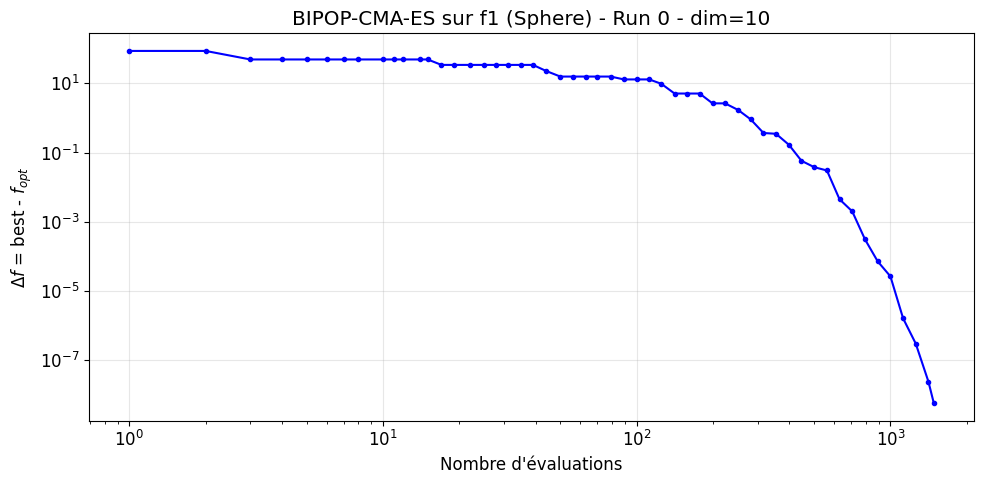

In [6]:
# Visualisation d'un seul run pour un algorithme et une fonction
def plot_single_run(algo_name, func_id, run_id=0):
    """Trace la courbe de convergence d'un seul run."""
    if func_id not in all_data.get(algo_name, {}):
        print(f"Données non disponibles pour {algo_name}/f{func_id}")
        return
    
    runs = all_data[algo_name][func_id]
    if run_id not in runs:
        run_id = list(runs.keys())[0]
    
    data = runs[run_id]
    evals = [d[0] for d in data]
    delta_f = [max(d[1], 1e-15) for d in data]  # Éviter log(0)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(evals, delta_f, 'b-o', markersize=3, linewidth=1.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Nombre d'évaluations")
    ax.set_ylabel(r"$\Delta f$ = best - $f_{opt}$")
    ax.set_title(f"{algo_name} sur f{func_id} ({FUNC_NAMES[func_id]}) - Run {run_id} - dim={DIM}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"single_run_{algo_name}_f{func_id}.pdf", bbox_inches='tight')
    plt.show()

# Exemple : BIPOP-CMA-ES sur f1
plot_single_run("BIPOP-CMA-ES", 1)

## 7. Analyse multi-runs par algorithme (Étape 2)

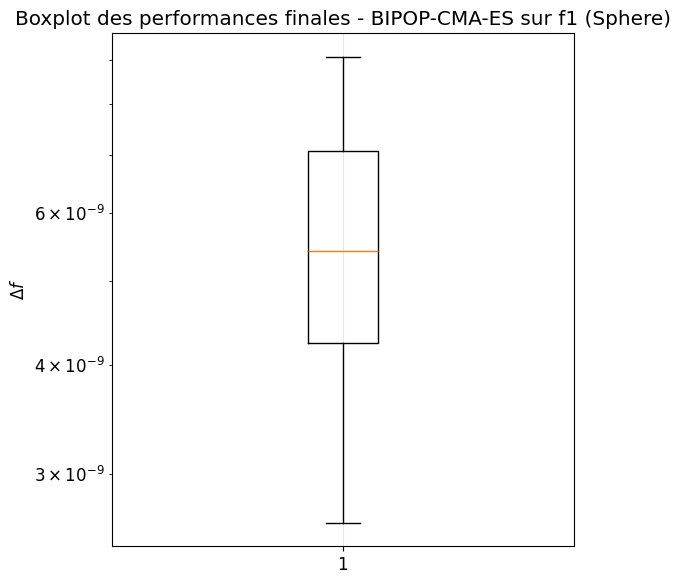

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_boxplot_f1(algo_name, func_id=1):
    """Boxplot des performances finales pour f1 (plusieurs runs)."""
    
    if func_id not in all_data.get(algo_name, {}):
        print(f"Données non disponibles pour {algo_name}/f{func_id}")
        return
    
    runs = all_data[algo_name][func_id]
    
    final_values = []

    # Récupérer la valeur finale de chaque run
    for run in runs.values():
        if len(run) > 0:
            final_df = max(run[-1][1], 1e-15)
            final_values.append(final_df)

    plt.figure(figsize=(6, 6))
    
    plt.boxplot(final_values, vert=True)
    plt.yscale('log')
    
    plt.ylabel(r"$\Delta f$")
    plt.title(f"Boxplot des performances finales - {algo_name} sur f{func_id} (Sphere)")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Sauvegarde
    plt.savefig("boxplot.pdf", bbox_inches='tight')
    plt.show()


# Appel
plot_boxplot_f1("BIPOP-CMA-ES", 1)

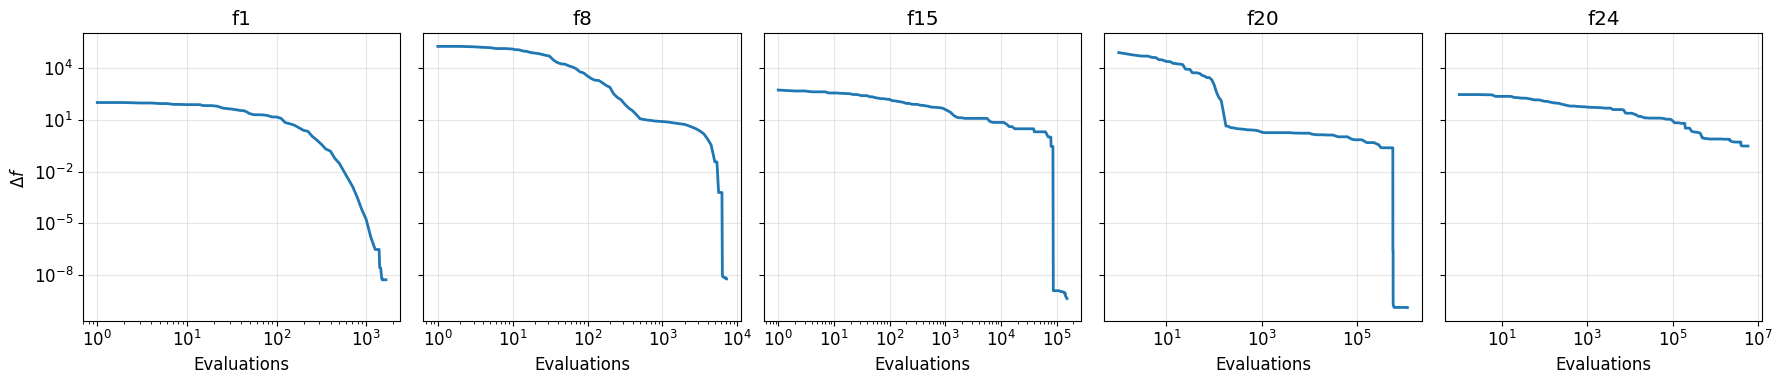

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence_all_functions(algo_name):
    fig, axes = plt.subplots(1, len(FUNC_IDS), figsize=(18, 4), sharey=True)

    for i, fid in enumerate(FUNC_IDS):
        ax = axes[i]
        
        if fid not in all_data.get(algo_name, {}):
            continue
        
        runs = all_data[algo_name][fid]

        # Médiane
        all_evals = sorted(set(e for run in runs.values() for e, _ in run))
        medians = []
        valid_evals = []

        for ev in all_evals:
            vals = []
            for run in runs.values():
                v = [df for e, df in run if e <= ev]
                if v:
                    vals.append(max(v[-1], 1e-15))
            if len(vals) >= 2:
                valid_evals.append(ev)
                medians.append(np.median(vals))

        ax.plot(valid_evals, medians, linewidth=2, label=algo_name)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f"f{fid}")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$\Delta f$")
    for ax in axes:
        ax.set_xlabel("Evaluations")

    plt.tight_layout()
    plt.savefig("convergence_all_functions.pdf", bbox_inches='tight')
    plt.show()


# Appel
plot_convergence_all_functions("BIPOP-CMA-ES")

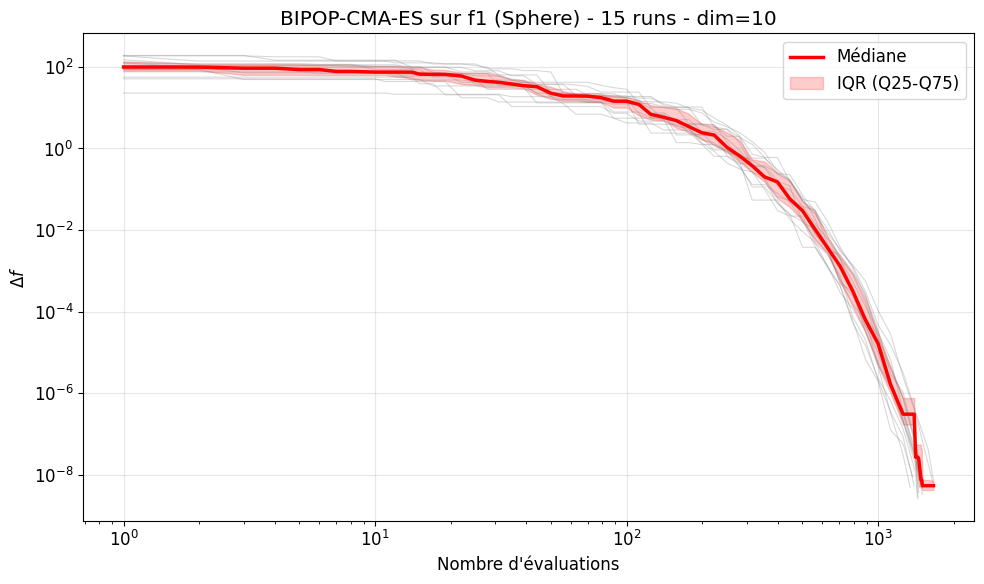

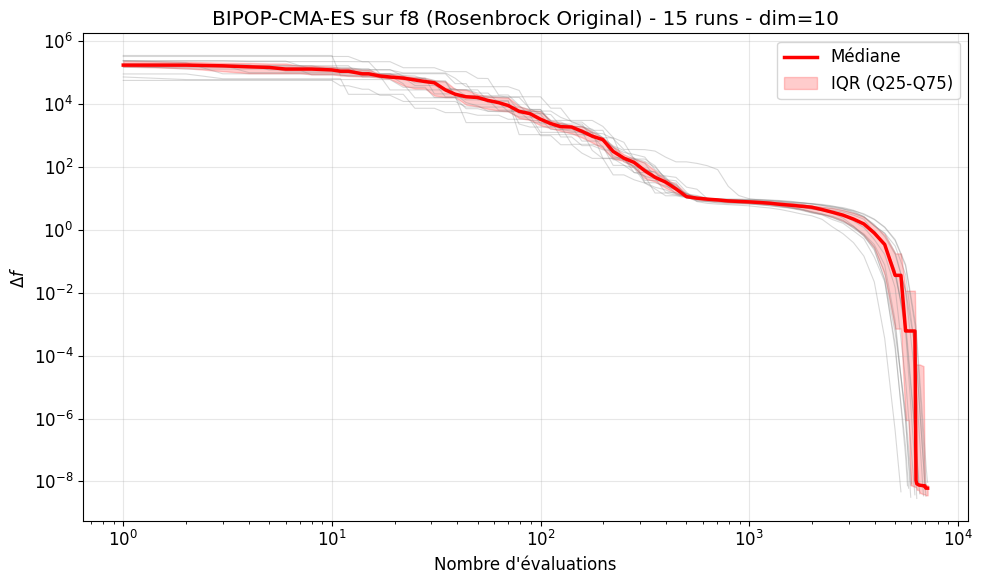

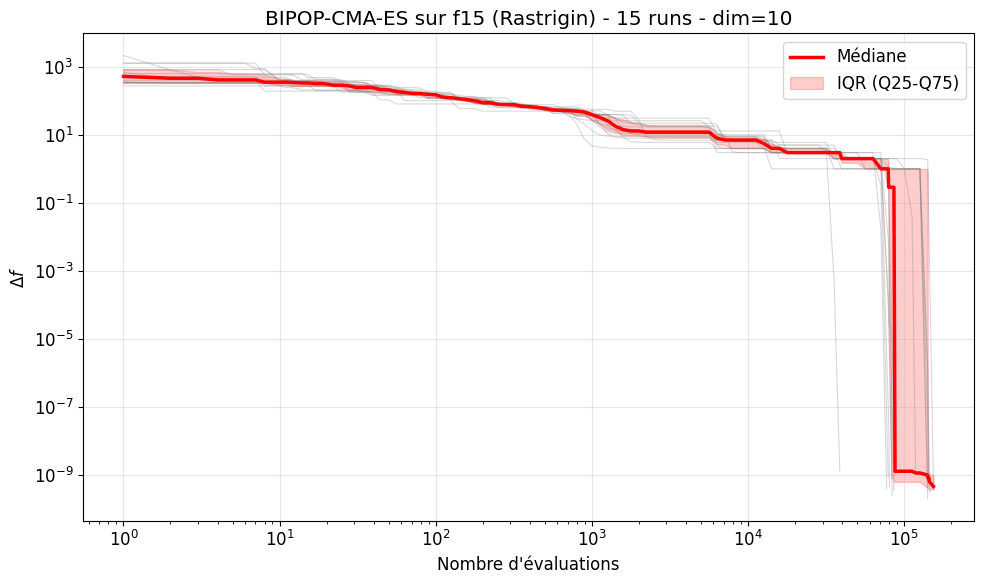

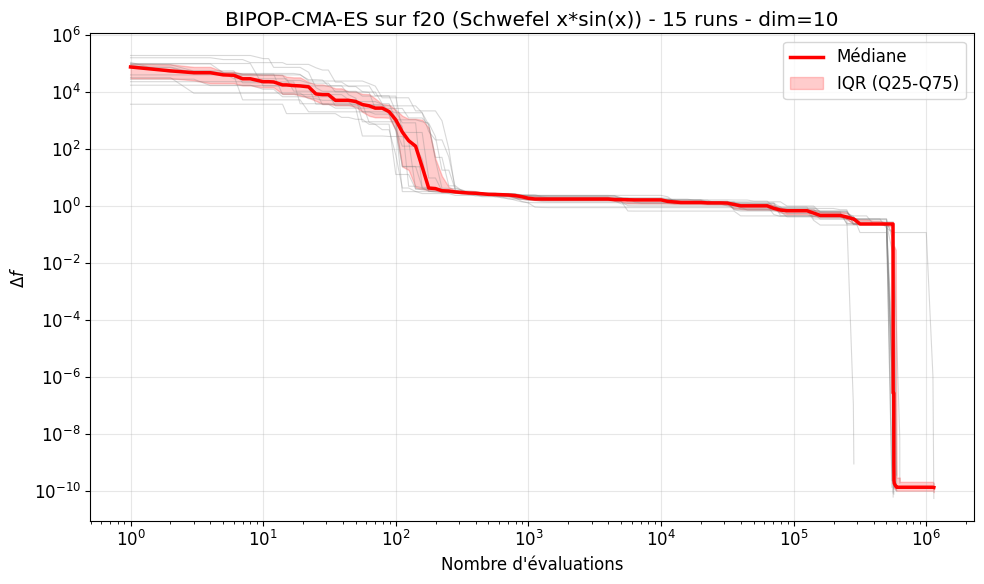

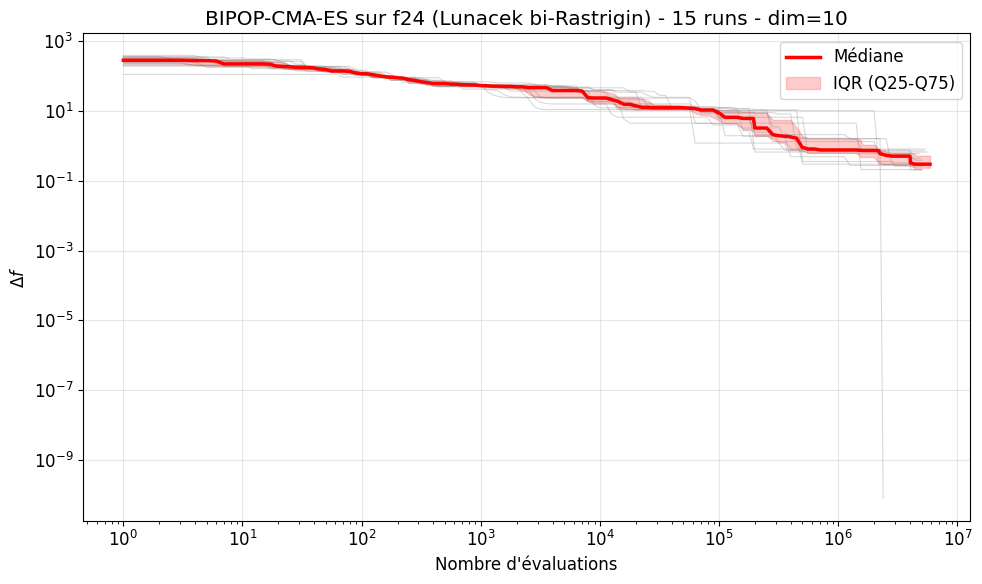

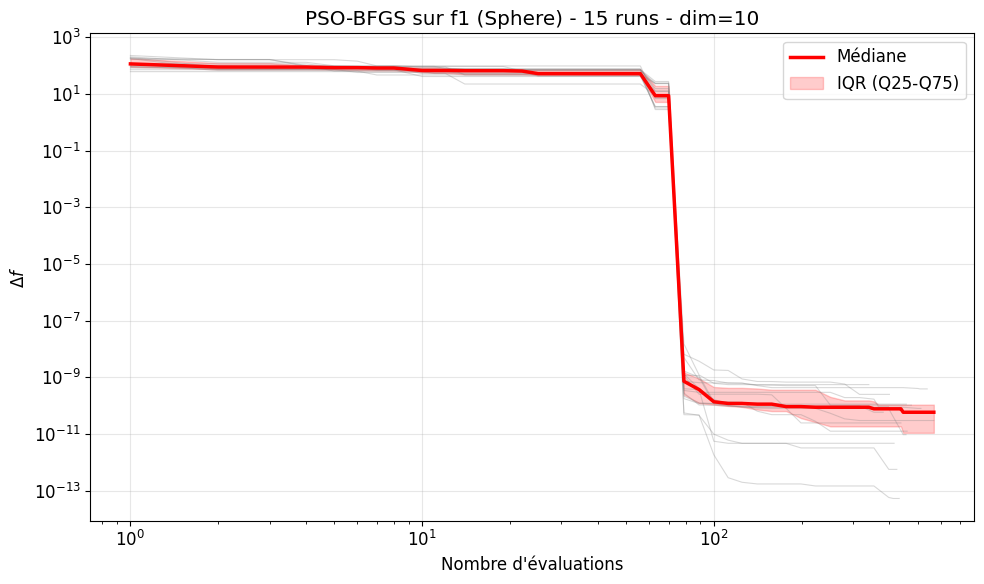

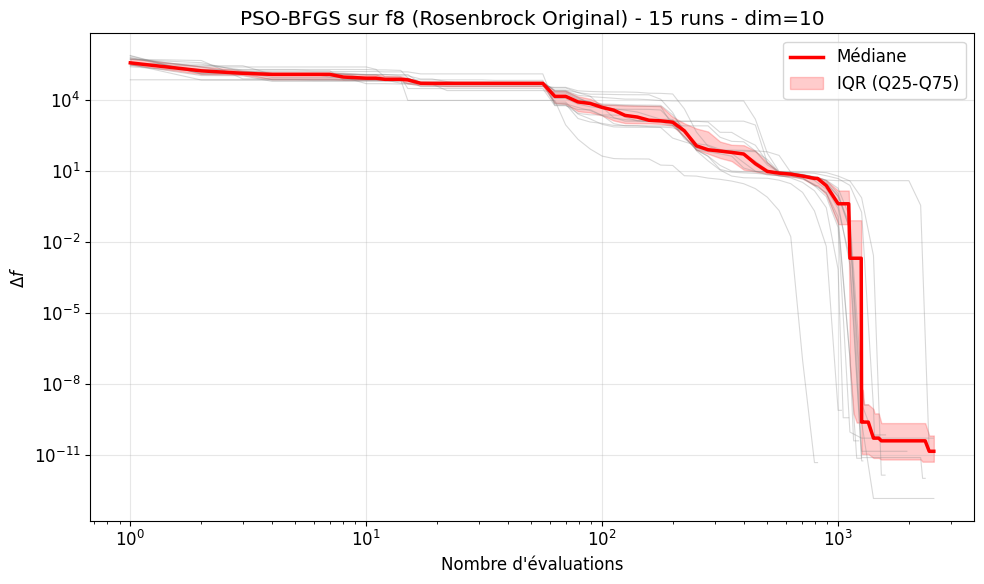

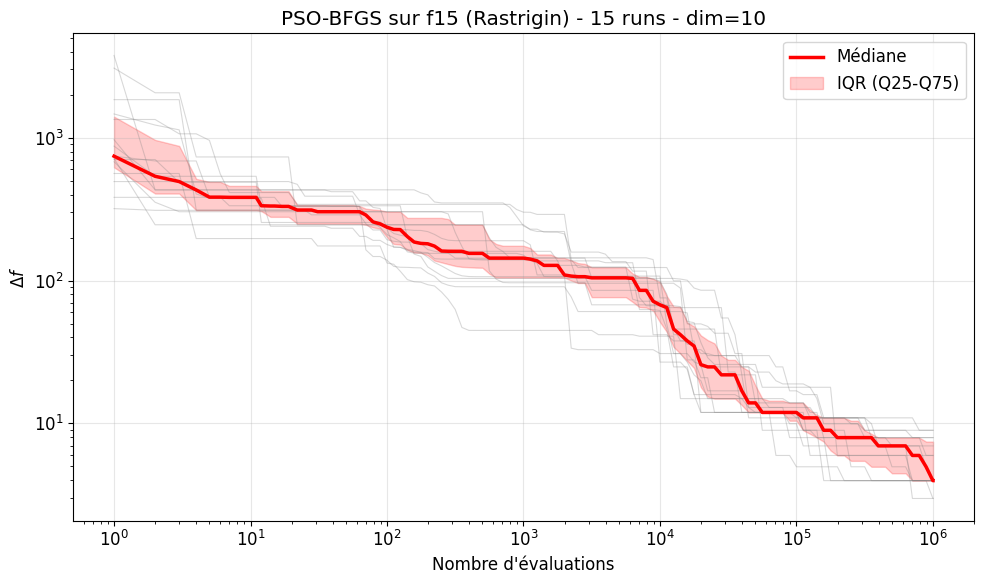

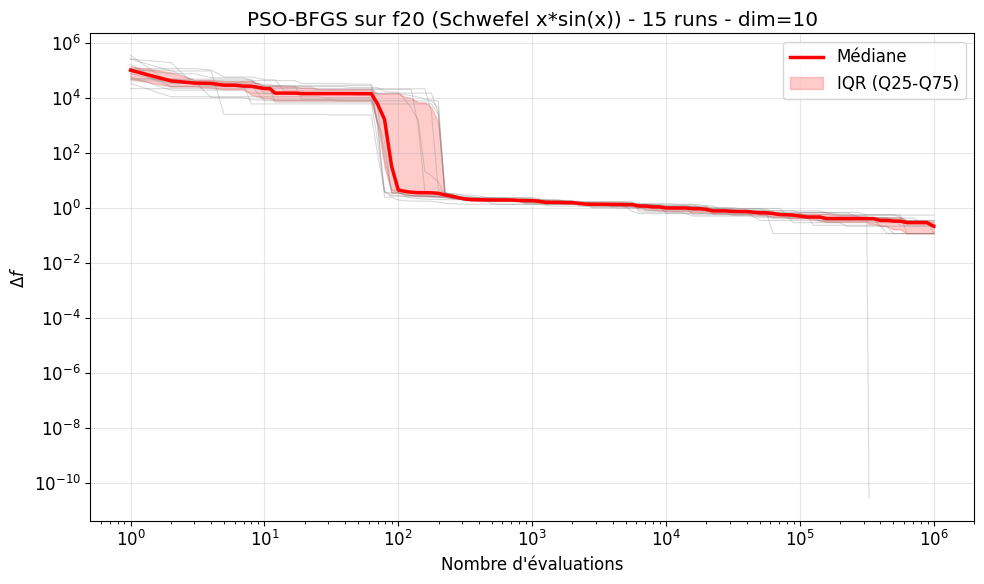

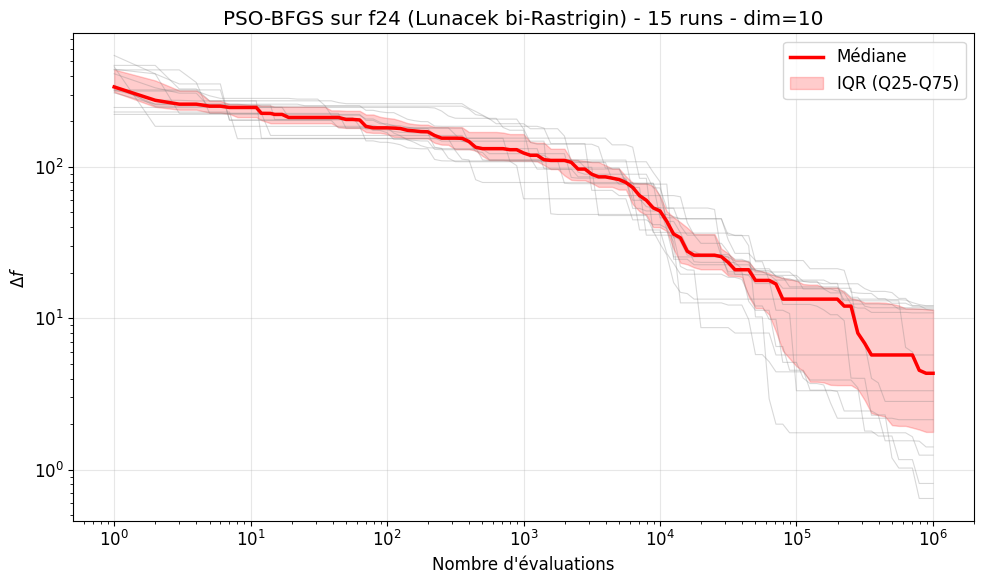

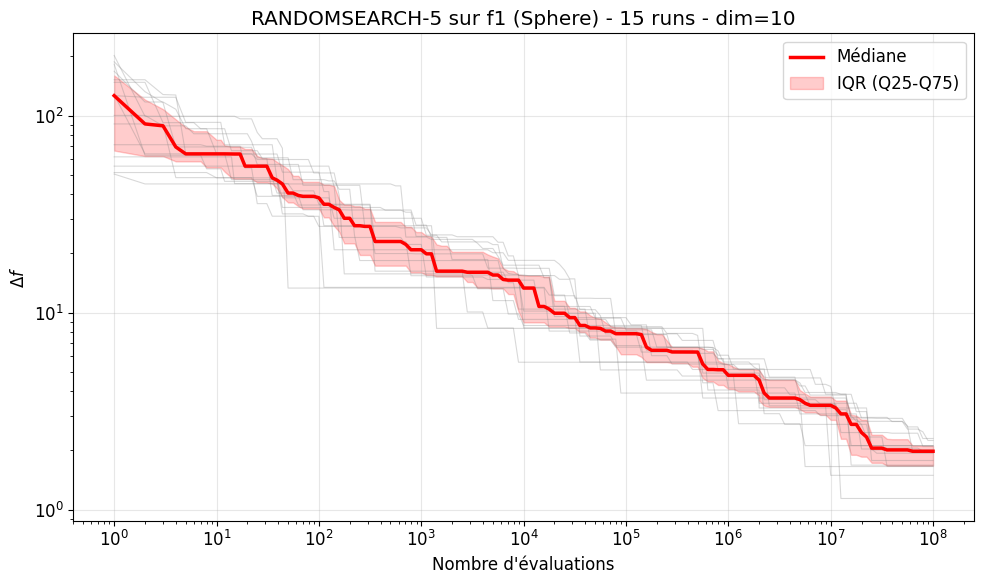

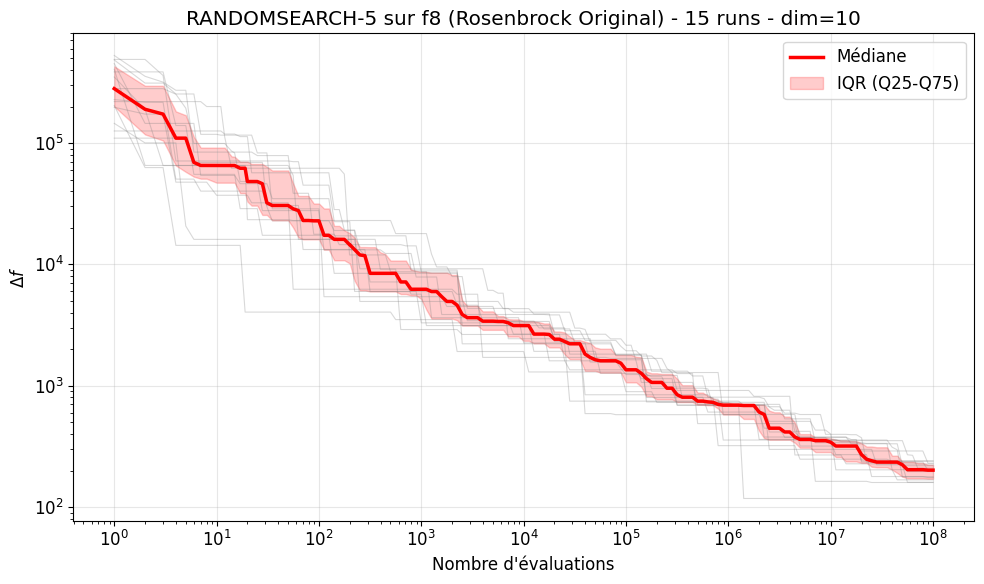

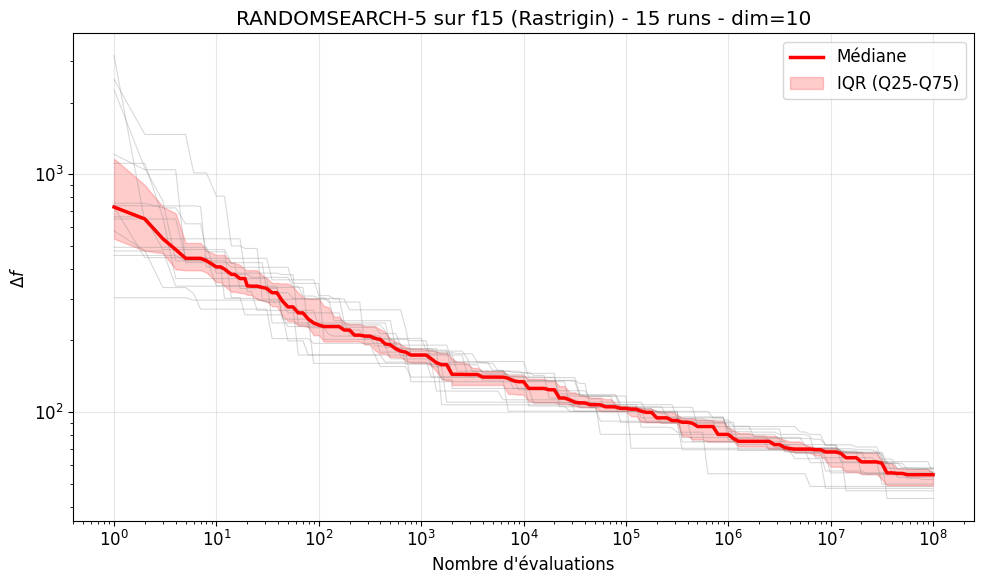

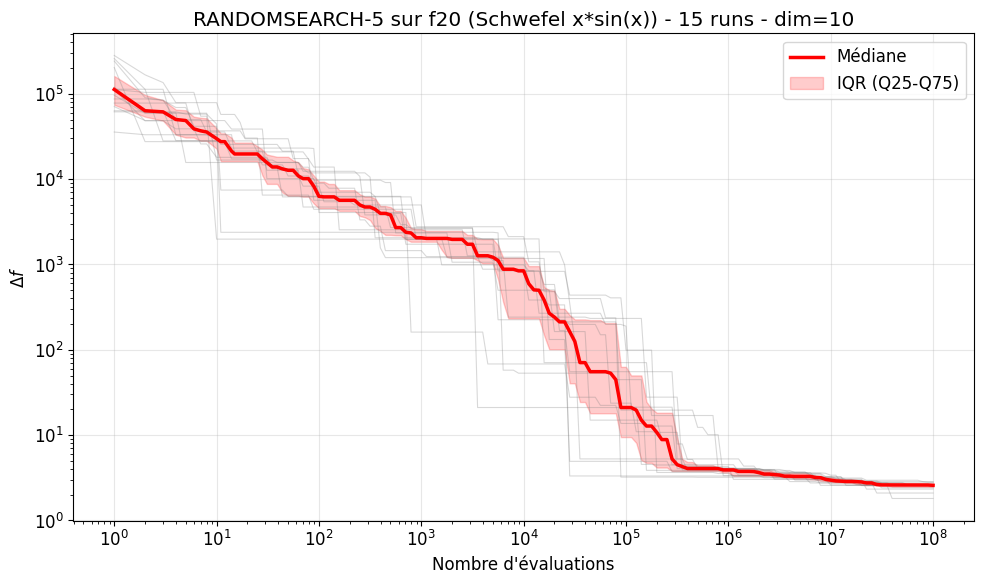

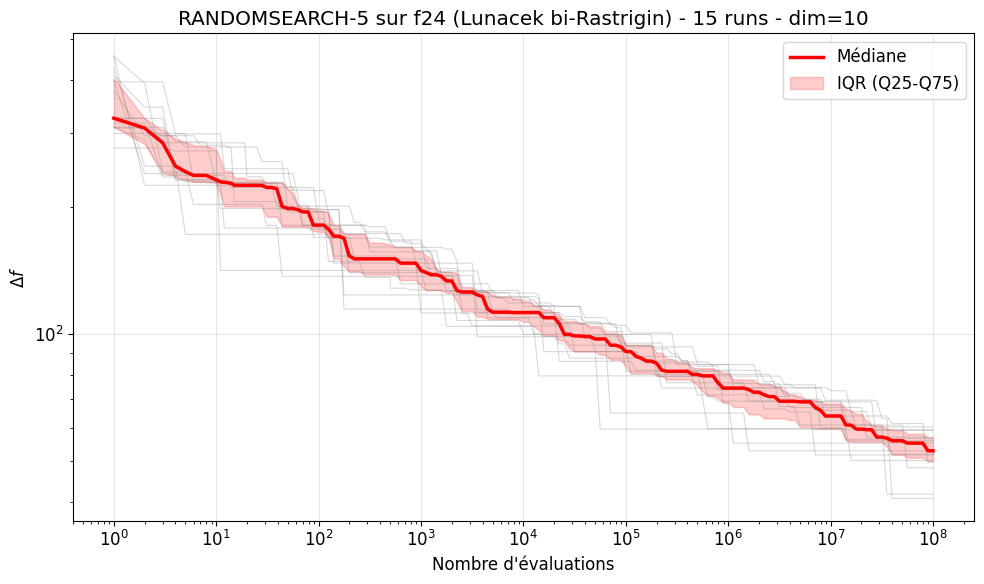

In [9]:
def plot_all_runs(algo_name, func_id):
    """Trace toutes les runs superposées + médiane."""
    if func_id not in all_data.get(algo_name, {}):
        print(f"Données non disponibles pour {algo_name}/f{func_id}")
        return
    
    runs = all_data[algo_name][func_id]
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Tracer chaque run en gris transparent
    for rid, data in runs.items():
        evals = [d[0] for d in data]
        delta_f = [max(d[1], 1e-15) for d in data]
        ax.plot(evals, delta_f, color='gray', alpha=0.3, linewidth=0.8)
    
    # Calculer et tracer la médiane
    all_evals = sorted(set(e for run in runs.values() for e, _ in run))
    medians = []
    q25s = []
    q75s = []
    valid_evals = []
    
    for ev in all_evals:
        vals = []
        for run in runs.values():
            v = [df for e, df in run if e <= ev]
            if v:
                vals.append(max(v[-1], 1e-15))
        if len(vals) >= 2:
            valid_evals.append(ev)
            medians.append(np.median(vals))
            q25s.append(np.percentile(vals, 25))
            q75s.append(np.percentile(vals, 75))
    
    ax.plot(valid_evals, medians, 'r-', linewidth=2.5, label='Médiane')
    ax.fill_between(valid_evals, q25s, q75s, alpha=0.2, color='red', label='IQR (Q25-Q75)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Nombre d'évaluations")
    ax.set_ylabel(r"$\Delta f$")
    ax.set_title(f"{algo_name} sur f{func_id} ({FUNC_NAMES[func_id]}) - {len(runs)} runs - dim={DIM}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"all_runs_{algo_name}_f{func_id}.pdf", bbox_inches='tight')
    plt.show()

# Tracer pour chaque algo et chaque fonction
for algo in ALGOS:
    for fid in FUNC_IDS:
        plot_all_runs(algo, fid)

## 8. Courbes de convergence comparatives (Étape 3)

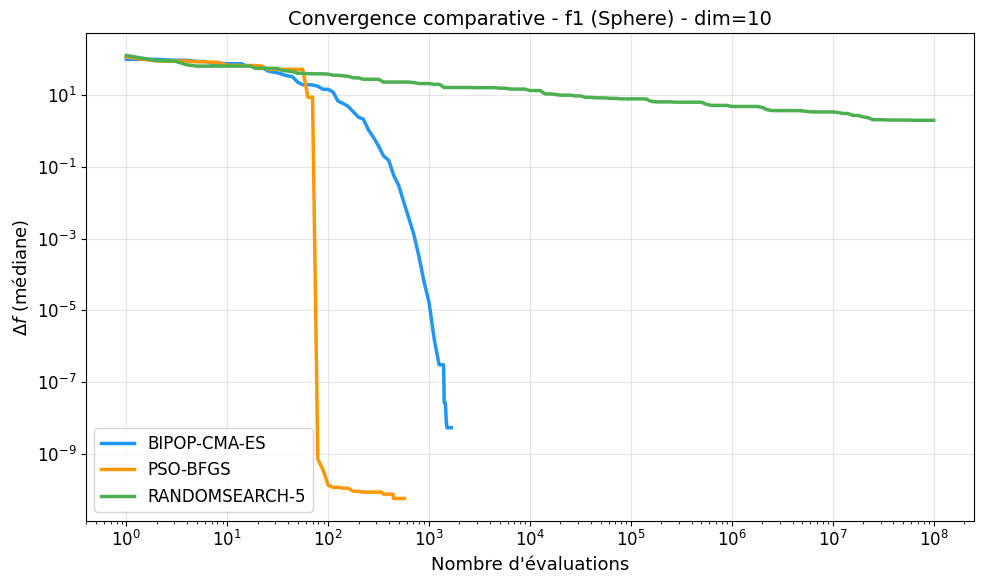

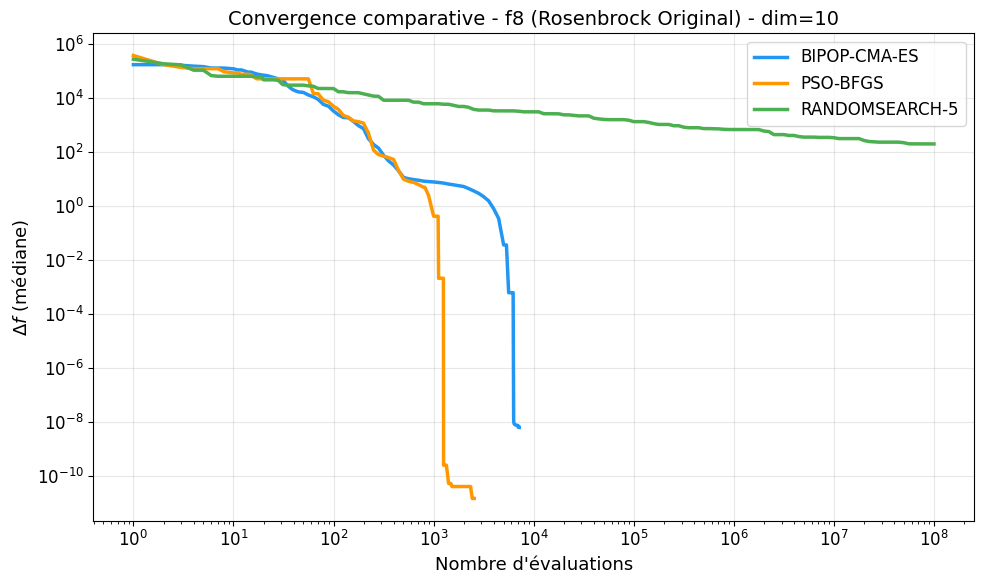

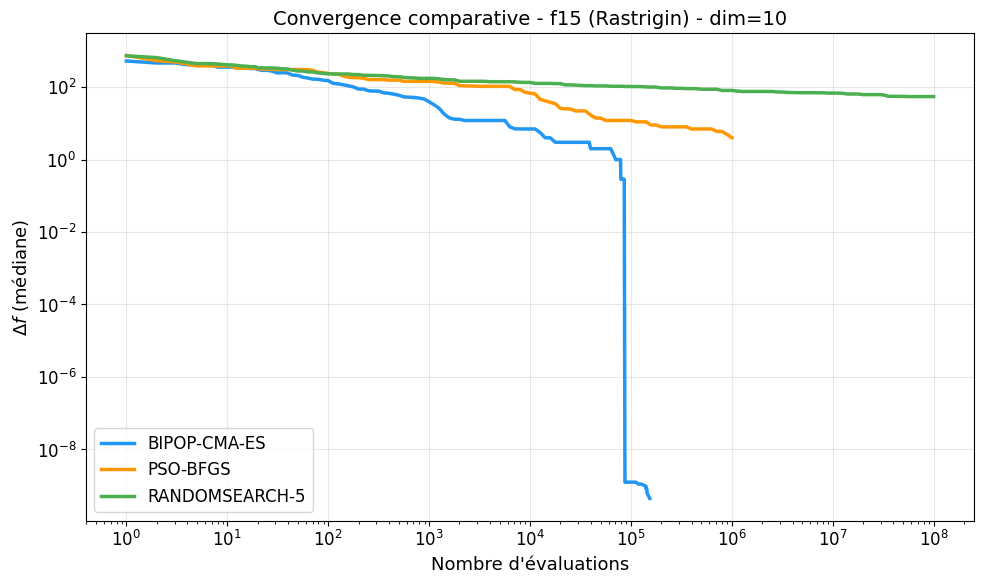

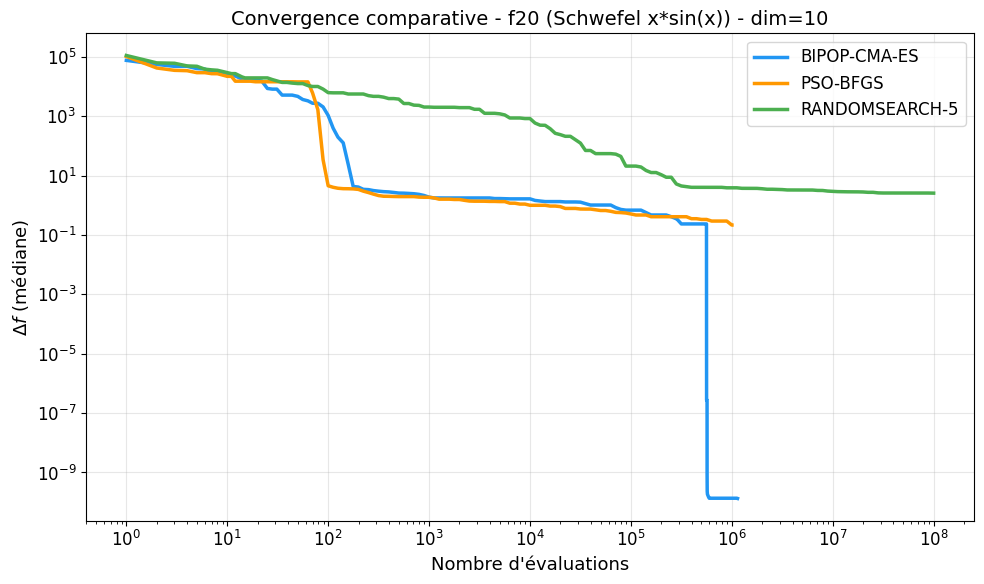

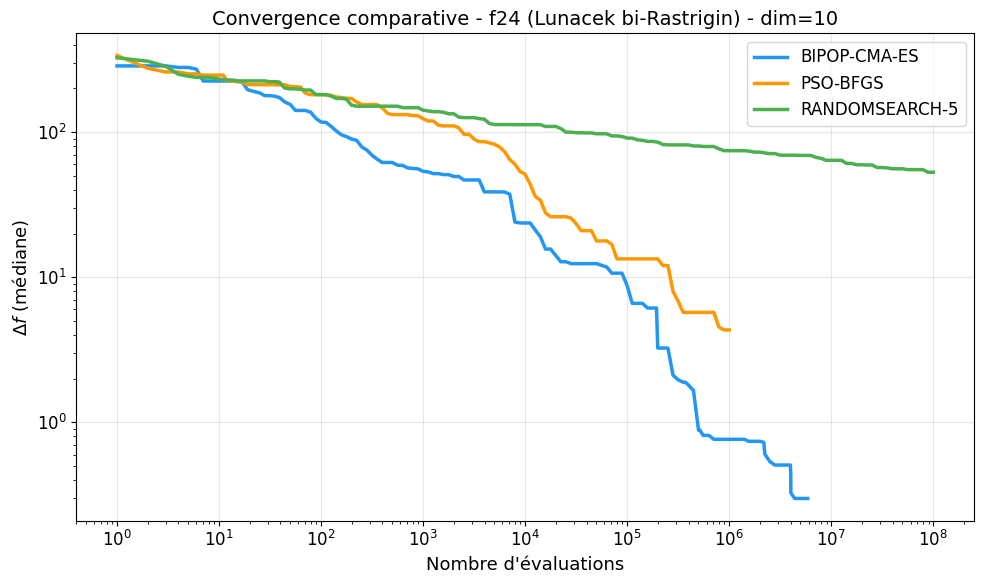

In [10]:
COLORS = {
    'BIPOP-CMA-ES': '#2196F3',
    'PSO-BFGS': '#FF9800',
    'RANDOMSEARCH-5': '#4CAF50'
}

def compute_median_convergence(algo_name, func_id):
    """Calcule la convergence médiane."""
    if func_id not in all_data.get(algo_name, {}):
        return [], []
    
    runs = all_data[algo_name][func_id]
    all_evals = sorted(set(e for run in runs.values() for e, _ in run))
    
    valid_evals = []
    medians = []
    
    for ev in all_evals:
        vals = []
        for run in runs.values():
            v = [df for e, df in run if e <= ev]
            if v:
                vals.append(max(v[-1], 1e-15))
        if len(vals) >= 2:
            valid_evals.append(ev)
            medians.append(np.median(vals))
    
    return valid_evals, medians


def plot_convergence_comparison(func_id):
    """Compare les courbes de convergence des 3 algorithmes."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo_name in ALGOS:
        evals, medians = compute_median_convergence(algo_name, func_id)
        if evals:
            ax.plot(evals, medians, color=COLORS[algo_name], 
                    linewidth=2.5, label=algo_name)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Nombre d'évaluations", fontsize=13)
    ax.set_ylabel(r"$\Delta f$ (médiane)", fontsize=13)
    ax.set_title(f"Convergence comparative - f{func_id} ({FUNC_NAMES[func_id]}) - dim={DIM}", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"convergence_f{func_id}.pdf", bbox_inches='tight')
    plt.show()

# Courbes de convergence pour les 5 fonctions
for fid in FUNC_IDS:
    plot_convergence_comparison(fid)

## 9. Boîtes à moustaches

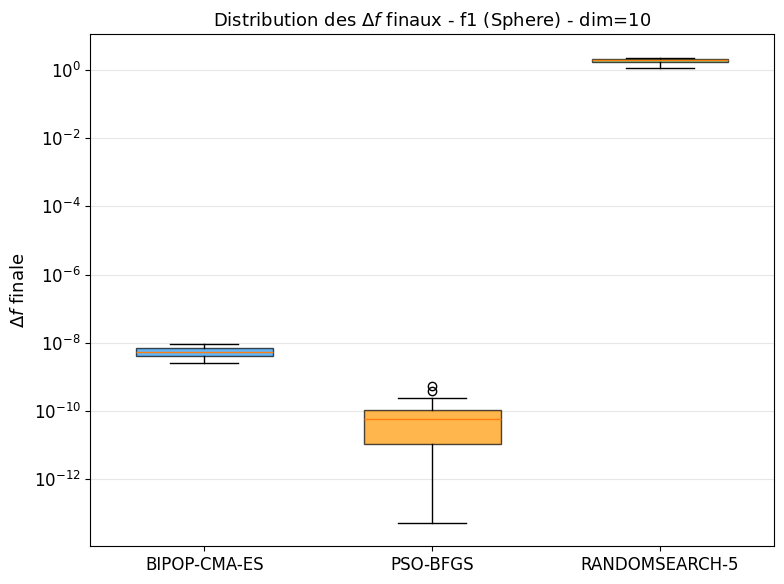

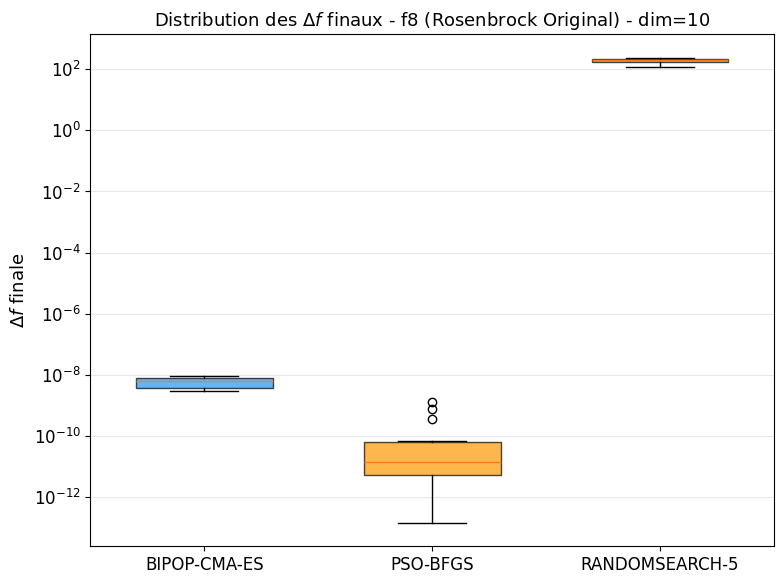

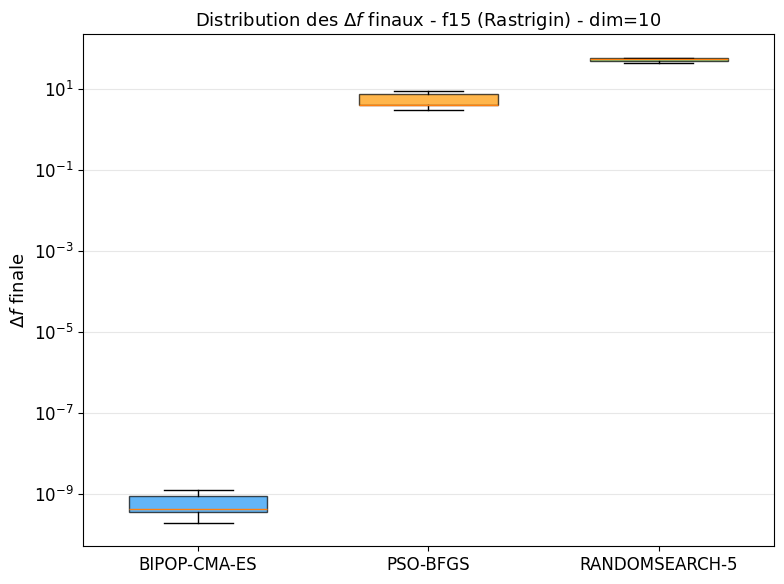

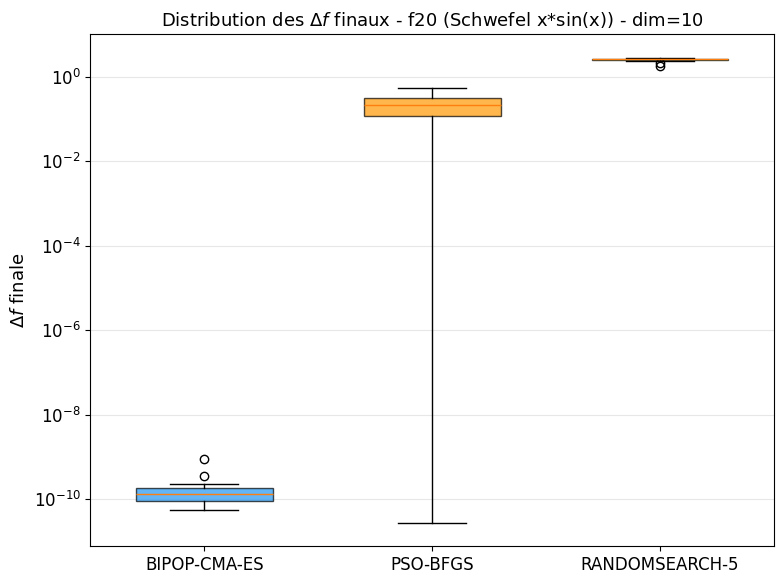

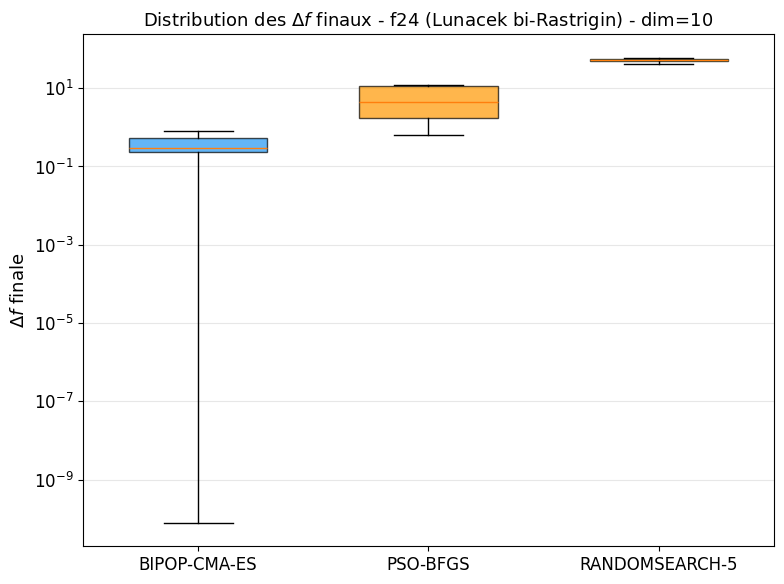

In [11]:
def get_final_values(algo_name, func_id):
    """Récupère la dernière valeur de delta_f pour chaque run."""
    if func_id not in all_data.get(algo_name, {}):
        return []
    runs = all_data[algo_name][func_id]
    finals = []
    for run in runs.values():
        if run:
            finals.append(max(run[-1][1], 1e-15))
    return finals


def plot_boxplots(func_id):
    """Boxplots des delta_f finaux."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    data = []
    labels = []
    colors_list = []
    
    for algo in ALGOS:
        vals = get_final_values(algo, func_id)
        if vals:
            data.append(vals)
            labels.append(algo)
            colors_list.append(COLORS[algo])
    
    if not data:
        print(f"Pas de données pour f{func_id}")
        return
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    widths=0.6, showfliers=True)
    
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_yscale('log')
    ax.set_ylabel(r"$\Delta f$ finale", fontsize=13)
    ax.set_title(f"Distribution des $\Delta f$ finaux - f{func_id} ({FUNC_NAMES[func_id]}) - dim={DIM}", fontsize=13)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"boxplot_f{func_id}.pdf", bbox_inches='tight')
    plt.show()

# Boxplots pour les 5 fonctions
for fid in FUNC_IDS:
    plot_boxplots(fid)

## 10. Vue d'ensemble : toutes les fonctions

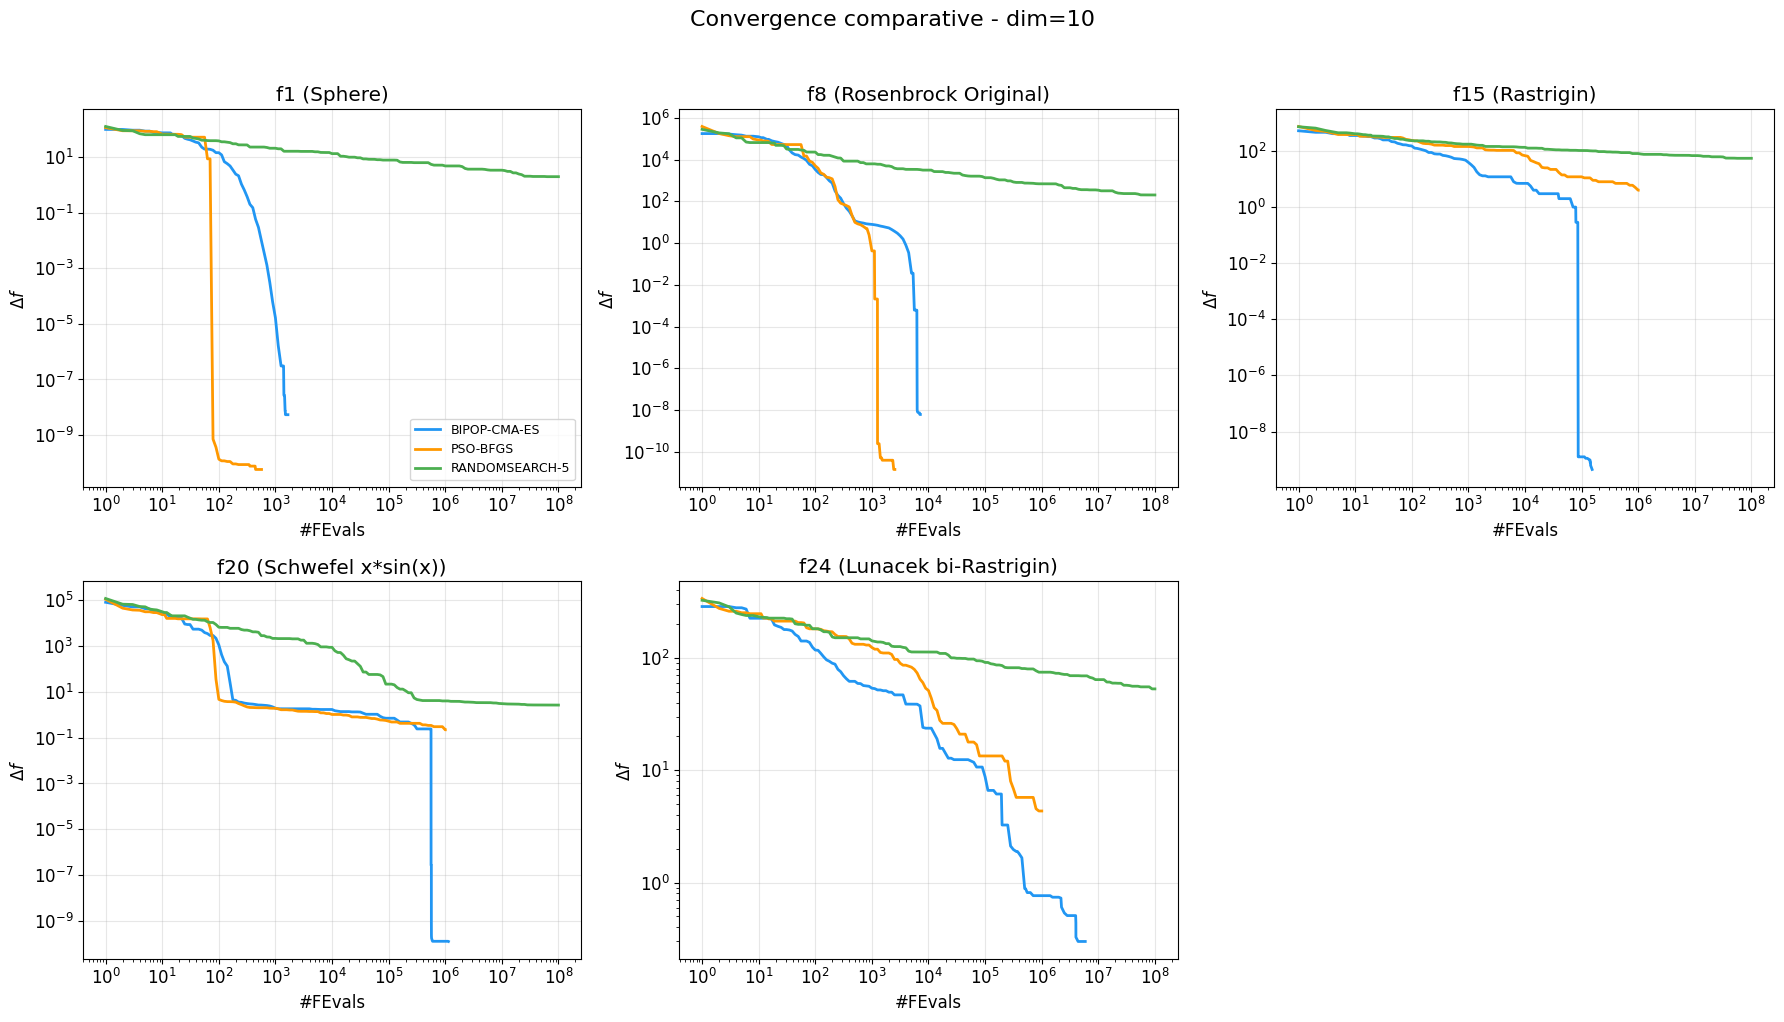

In [12]:
# Figure combinée : convergence de toutes les fonctions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, fid in enumerate(FUNC_IDS):
    ax = axes[idx]
    for algo_name in ALGOS:
        evals, medians = compute_median_convergence(algo_name, fid)
        if evals:
            ax.plot(evals, medians, color=COLORS[algo_name], 
                    linewidth=2, label=algo_name)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('#FEvals')
    ax.set_ylabel(r'$\Delta f$')
    ax.set_title(f'f{fid} ({FUNC_NAMES[fid]})')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9)

# Cacher le 6ème subplot
axes[5].set_visible(False)

plt.suptitle(f'Convergence comparative - dim={DIM}', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('convergence_all.pdf', bbox_inches='tight')
plt.show()

In [13]:
print(COLORS)


{'BIPOP-CMA-ES': '#2196F3', 'PSO-BFGS': '#FF9800', 'RANDOMSEARCH-5': '#4CAF50'}


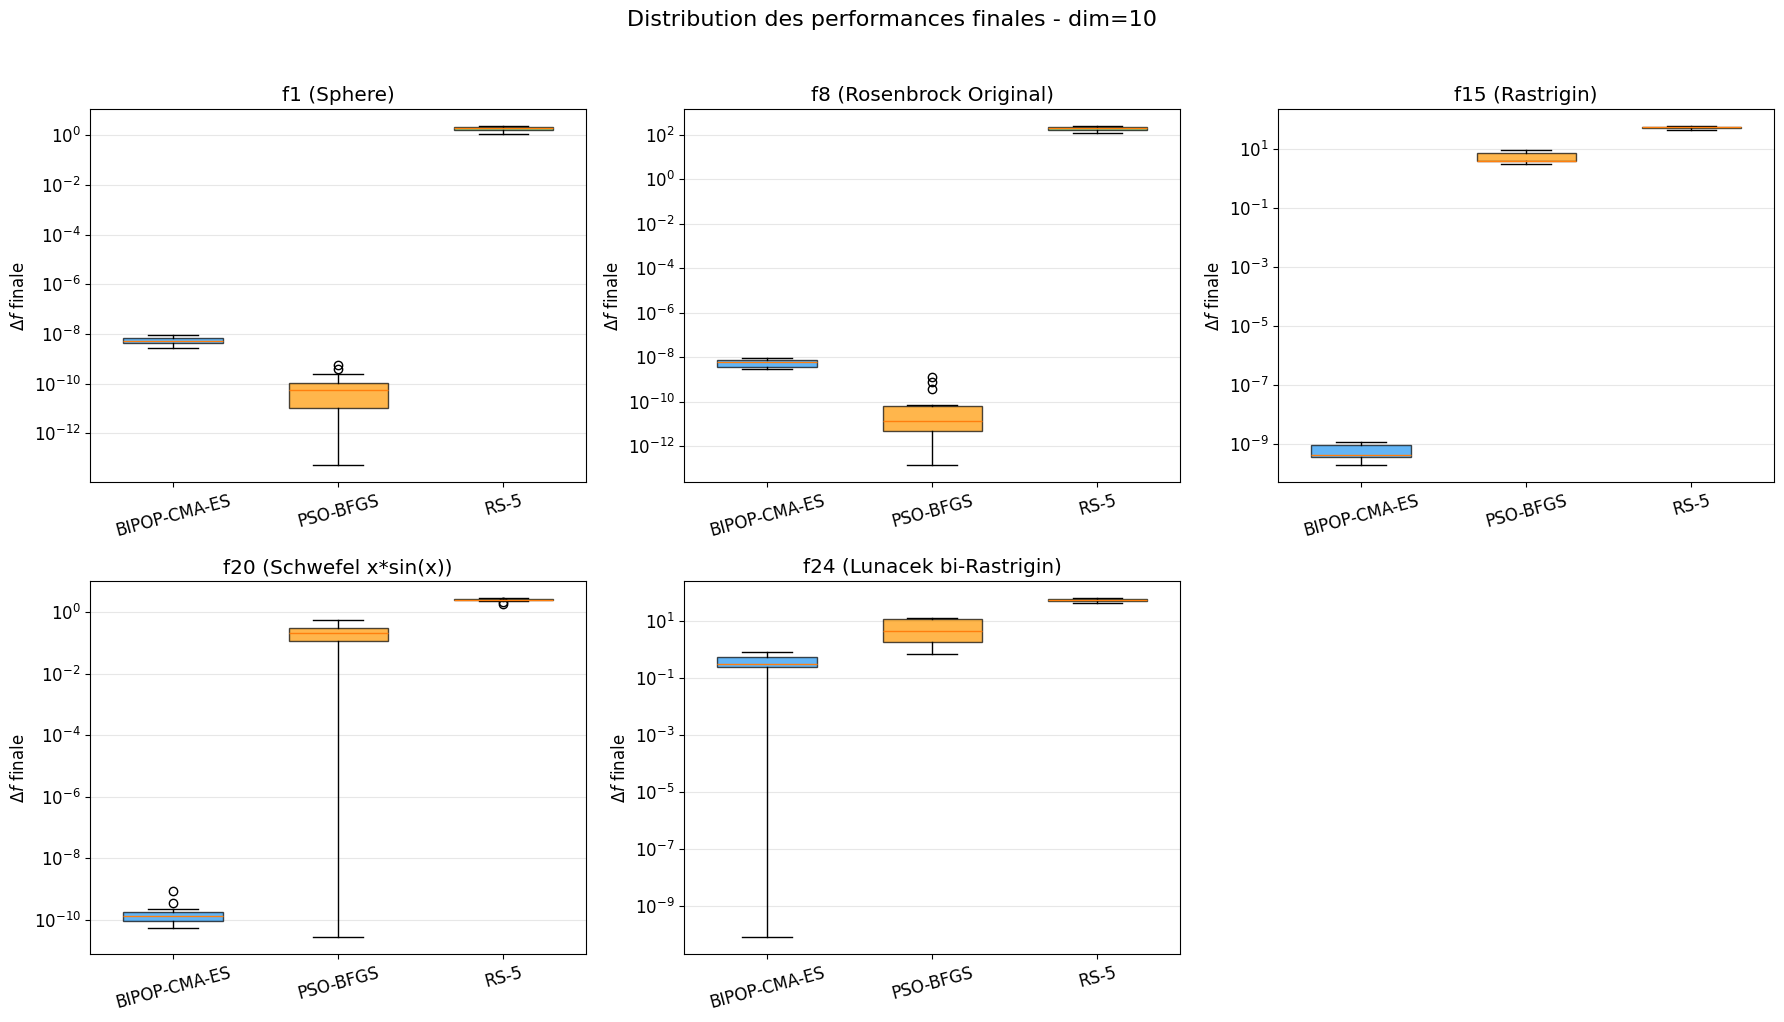

In [14]:
# Figure combinée : boxplots de toutes les fonctions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, fid in enumerate(FUNC_IDS):
    ax = axes[idx]
    data = []
    labels = []
    colors_list = []
    for algo in ALGOS:
        vals = get_final_values(algo, fid)
        if vals:
            data.append(vals)
            labels.append(algo.replace('RANDOMSEARCH-5', 'RS-5'))
            colors_list.append(COLORS[algo])
    
    if data:
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6)
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    
    ax.set_yscale('log')
    ax.set_title(f'f{fid} ({FUNC_NAMES[fid]})')
    ax.set_ylabel(r'$\Delta f$ finale')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

axes[5].set_visible(False)

plt.suptitle(f'Distribution des performances finales - dim={DIM}', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_all.pdf', bbox_inches='tight')
plt.show()

## 11. Statistiques descriptives

In [15]:
def descriptive_stats(func_id):
    """Calcule les statistiques descriptives pour une fonction."""
    rows = []
    for algo in ALGOS:
        vals = np.array(get_final_values(algo, func_id))
        if len(vals) == 0:
            continue
        rows.append({
            'Algorithme': algo,
            'N_runs': len(vals),
            'Moyenne': f"{np.mean(vals):.2e}",
            'Médiane': f"{np.median(vals):.2e}",
            'Écart-type': f"{np.std(vals):.2e}",
            'Min': f"{np.min(vals):.2e}",
            'Max': f"{np.max(vals):.2e}",
            'Q25': f"{np.percentile(vals, 25):.2e}",
            'Q75': f"{np.percentile(vals, 75):.2e}",
        })
    return pd.DataFrame(rows)

# Afficher les statistiques pour chaque fonction
for fid in FUNC_IDS:
    print(f"\n{'='*80}")
    print(f"  f{fid} - {FUNC_NAMES[fid]} (dim={DIM})")
    print(f"{'='*80}")
    df = descriptive_stats(fid)
    if not df.empty:
        display(df)


  f1 - Sphere (dim=10)


,Algorithme,N_runs,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,BIPOP-CMA-ES,15,5.55e-09,5.41e-09,1.84e-09,2.63e-09,9.08e-09,4.24e-09,7.06e-09
1,PSO-BFGS,15,1.14e-10,5.80e-11,1.55e-10,5.24e-14,5.48e-10,1.09e-11,1.07e-10
2,RANDOMSEARCH-5,15,1.88e+00,1.98e+00,3.00e-01,1.14e+00,2.30e+00,1.67e+00,2.11e+00



  f8 - Rosenbrock Original (dim=10)


,Algorithme,N_runs,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,BIPOP-CMA-ES,15,5.78e-09,6.08e-09,2.17e-09,2.86e-09,9.32e-09,3.60e-09,7.63e-09
1,PSO-BFGS,15,1.79e-10,1.41e-11,3.57e-10,1.42e-13,1.29e-09,5.11e-12,6.56e-11
2,RANDOMSEARCH-5,15,1.95e+02,2.01e+02,3.36e+01,1.18e+02,2.41e+02,1.71e+02,2.23e+02



  f15 - Rastrigin (dim=10)


,Algorithme,N_runs,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,BIPOP-CMA-ES,15,6.36e-10,4.44e-10,3.49e-10,1.98e-10,1.25e-09,3.62e-10,9.23e-10
1,PSO-BFGS,15,5.51e+00,3.98e+00,2.08e+00,2.98e+00,8.95e+00,3.98e+00,7.46e+00
2,RANDOMSEARCH-5,15,5.27e+01,5.45e+01,4.37e+00,4.33e+01,5.82e+01,4.92e+01,5.56e+01



  f20 - Schwefel x*sin(x) (dim=10)


,Algorithme,N_runs,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,BIPOP-CMA-ES,15,1.91e-10,1.33e-10,2.02e-10,5.46e-11,8.93e-10,9.14e-11,1.86e-10
1,PSO-BFGS,15,2.26e-01,2.17e-01,1.33e-01,2.71e-11,5.53e-01,1.18e-01,3.16e-01
2,RANDOMSEARCH-5,15,2.52e+00,2.58e+00,2.62e-01,1.81e+00,2.85e+00,2.47e+00,2.64e+00



  f24 - Lunacek bi-Rastrigin (dim=10)


,Algorithme,N_runs,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,BIPOP-CMA-ES,15,3.82e-01,2.99e-01,2.19e-01,7.84e-11,8.15e-01,2.37e-01,5.21e-01
1,PSO-BFGS,15,6.13e+00,4.33e+00,4.64e+00,6.46e-01,1.21e+01,1.78e+00,1.14e+01
2,RANDOMSEARCH-5,15,5.27e+01,5.29e+01,5.72e+00,4.07e+01,6.02e+01,4.99e+01,5.68e+01


## 12. Tests statistiques de Wilcoxon

In [16]:
def run_wilcoxon_tests(func_id, alpha=0.05):
    """Tests de Wilcoxon entre toutes les paires d'algorithmes."""
    algo_list = list(ALGOS.keys())
    results = []
    
    for i in range(len(algo_list)):
        for j in range(i + 1, len(algo_list)):
            a_vals = np.array(get_final_values(algo_list[i], func_id))
            b_vals = np.array(get_final_values(algo_list[j], func_id))
            
            if len(a_vals) == 0 or len(b_vals) == 0:
                continue
            
            # Aligner le nombre de samples
            n = min(len(a_vals), len(b_vals))
            a, b = a_vals[:n], b_vals[:n]
            
            try:
                # Test de Wilcoxon (rangs signés, échantillons appariés)
                stat, p_value = wilcoxon(a, b)
                test_type = "Wilcoxon signé"
            except (ValueError, ZeroDivisionError):
                # Fallback: Mann-Whitney U (non apparié)
                stat, p_value = mannwhitneyu(a, b, alternative='two-sided')
                test_type = "Mann-Whitney U"
            
            significant = "OUI *" if p_value < alpha else "NON"
            
            # Déterminer le meilleur (médiane la plus basse)
            med_a = np.median(a)
            med_b = np.median(b)
            winner = algo_list[i] if med_a < med_b else algo_list[j]
            
            results.append({
                'Algo A': algo_list[i],
                'Algo B': algo_list[j],
                'Test': test_type,
                'Statistique': f"{stat:.1f}",
                'p-value': f"{p_value:.4e}",
                f'Significatif (α={alpha})': significant,
                'Meilleur': winner,
            })
    
    return pd.DataFrame(results)


# Tests pour chaque fonction
for fid in FUNC_IDS:
    print(f"\n{'='*80}")
    print(f"  Tests de Wilcoxon - f{fid} ({FUNC_NAMES[fid]})")
    print(f"{'='*80}")
    df = run_wilcoxon_tests(fid)
    if not df.empty:
        display(df)


  Tests de Wilcoxon - f1 (Sphere)


,Algo A,Algo B,Test,Statistique,p-value,Significatif (α=0.05),Meilleur
0,BIPOP-CMA-ES,PSO-BFGS,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS
1,BIPOP-CMA-ES,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
2,PSO-BFGS,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS



  Tests de Wilcoxon - f8 (Rosenbrock Original)


,Algo A,Algo B,Test,Statistique,p-value,Significatif (α=0.05),Meilleur
0,BIPOP-CMA-ES,PSO-BFGS,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS
1,BIPOP-CMA-ES,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
2,PSO-BFGS,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS



  Tests de Wilcoxon - f15 (Rastrigin)


,Algo A,Algo B,Test,Statistique,p-value,Significatif (α=0.05),Meilleur
0,BIPOP-CMA-ES,PSO-BFGS,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
1,BIPOP-CMA-ES,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
2,PSO-BFGS,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS



  Tests de Wilcoxon - f20 (Schwefel x*sin(x))


,Algo A,Algo B,Test,Statistique,p-value,Significatif (α=0.05),Meilleur
0,BIPOP-CMA-ES,PSO-BFGS,Wilcoxon signé,1.0,1.2207e-04,OUI *,BIPOP-CMA-ES
1,BIPOP-CMA-ES,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
2,PSO-BFGS,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS



  Tests de Wilcoxon - f24 (Lunacek bi-Rastrigin)


,Algo A,Algo B,Test,Statistique,p-value,Significatif (α=0.05),Meilleur
0,BIPOP-CMA-ES,PSO-BFGS,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
1,BIPOP-CMA-ES,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,BIPOP-CMA-ES
2,PSO-BFGS,RANDOMSEARCH-5,Wilcoxon signé,0.0,6.1035e-05,OUI *,PSO-BFGS


## 13. Tableau récapitulatif global

In [17]:
# Tableau récapitulatif : médiane de delta_f finale par algo/fonction
summary_rows = []
for fid in FUNC_IDS:
    row = {'Fonction': f'f{fid} ({FUNC_NAMES[fid]})'}
    best_val = float('inf')
    best_algo = ''
    for algo in ALGOS:
        vals = get_final_values(algo, fid)
        if vals:
            med = np.median(vals)
            row[algo] = f"{med:.2e}"
            if med < best_val:
                best_val = med
                best_algo = algo
        else:
            row[algo] = "N/A"
    row['Meilleur'] = best_algo
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print("  TABLEAU RÉCAPITULATIF - Médiane de Δf finale (dim=10)")
print("="*80)
display(summary_df)


  TABLEAU RÉCAPITULATIF - Médiane de Δf finale (dim=10)


,Fonction,BIPOP-CMA-ES,PSO-BFGS,RANDOMSEARCH-5,Meilleur
0,f1 (Sphere),5.41e-09,5.80e-11,1.98e+00,PSO-BFGS
1,f8 (Rosenbrock Original),6.08e-09,1.41e-11,2.01e+02,PSO-BFGS
2,f15 (Rastrigin),4.44e-10,3.98e+00,5.45e+01,BIPOP-CMA-ES
3,f20 (Schwefel x*sin(x)),1.33e-10,2.17e-01,2.58e+00,BIPOP-CMA-ES
4,f24 (Lunacek bi-Rastrigin),2.99e-01,4.33e+00,5.29e+01,BIPOP-CMA-ES


## 14. Heatmap de performance relative

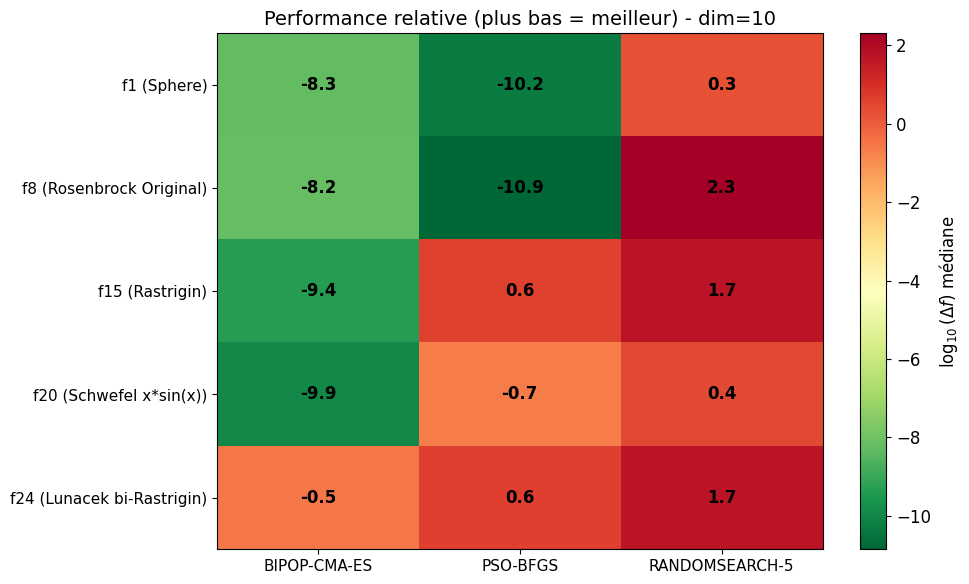

In [18]:
# Heatmap : log10(médiane delta_f) par algo/fonction
heatmap_data = []
for fid in FUNC_IDS:
    row = []
    for algo in ALGOS:
        vals = get_final_values(algo, fid)
        if vals:
            row.append(np.log10(np.median(vals)))
        else:
            row.append(np.nan)
    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(ALGOS)))
ax.set_xticklabels(list(ALGOS.keys()), fontsize=11)
ax.set_yticks(range(len(FUNC_IDS)))
ax.set_yticklabels([f'f{fid} ({FUNC_NAMES[fid]})' for fid in FUNC_IDS], fontsize=11)

# Annoter les cellules
for i in range(len(FUNC_IDS)):
    for j in range(len(ALGOS)):
        if not np.isnan(heatmap_data[i, j]):
            text = ax.text(j, i, f"{heatmap_data[i,j]:.1f}",
                          ha='center', va='center', fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\log_{10}(\Delta f)$ médiane', fontsize=12)
ax.set_title(f'Performance relative (plus bas = meilleur) - dim={DIM}', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_performance.pdf', bbox_inches='tight')
plt.show()

## 15. ECDF (Empirical Cumulative Distribution Functions)

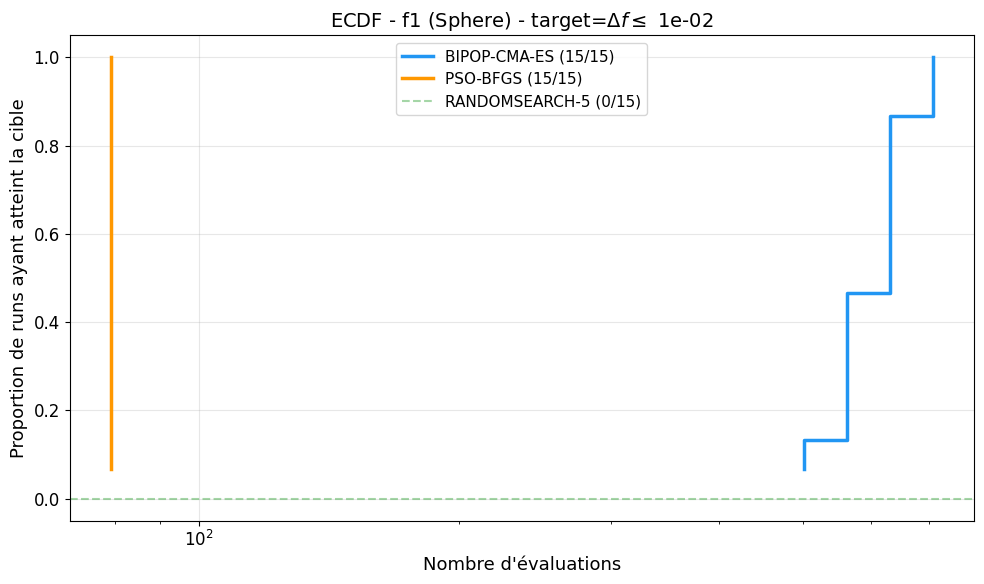

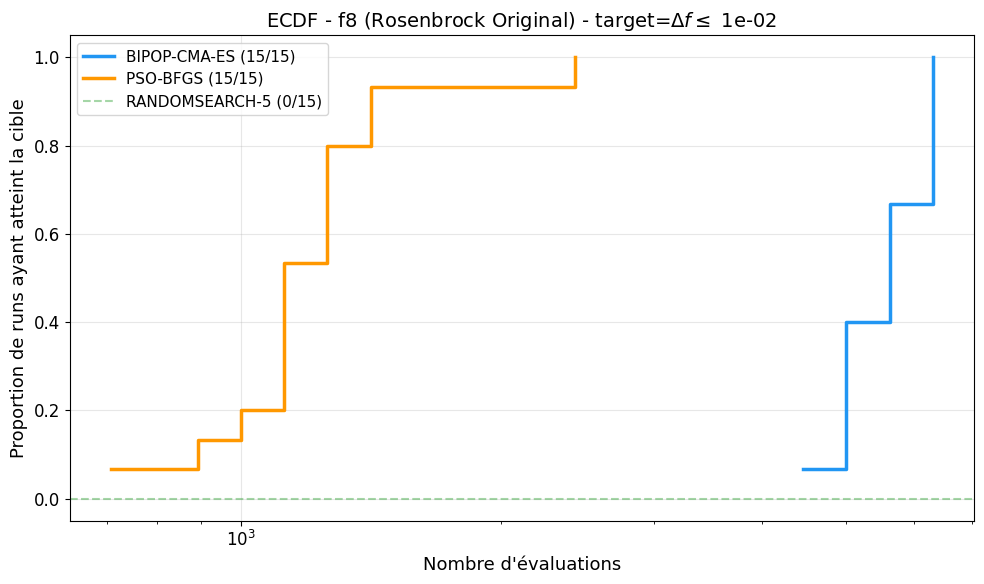

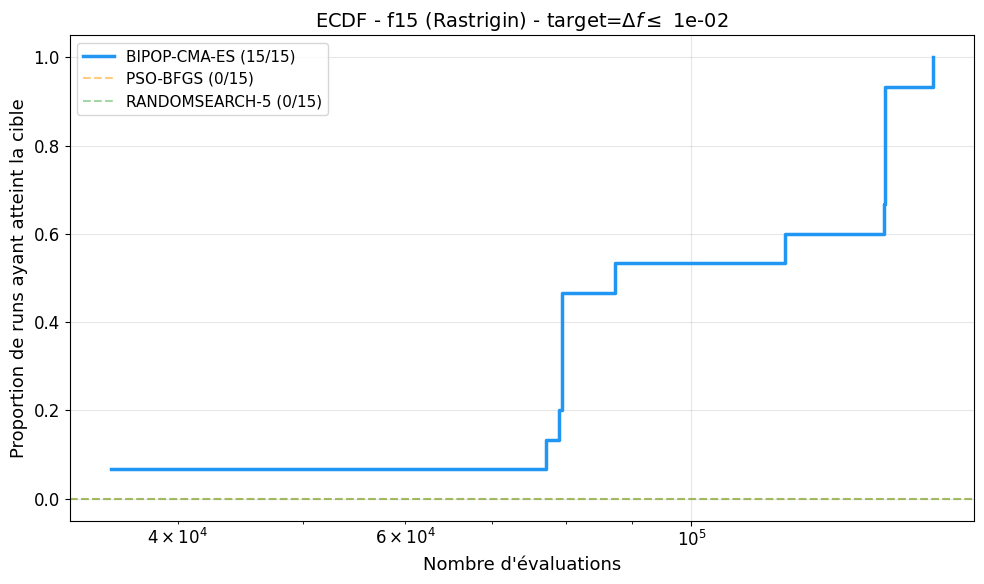

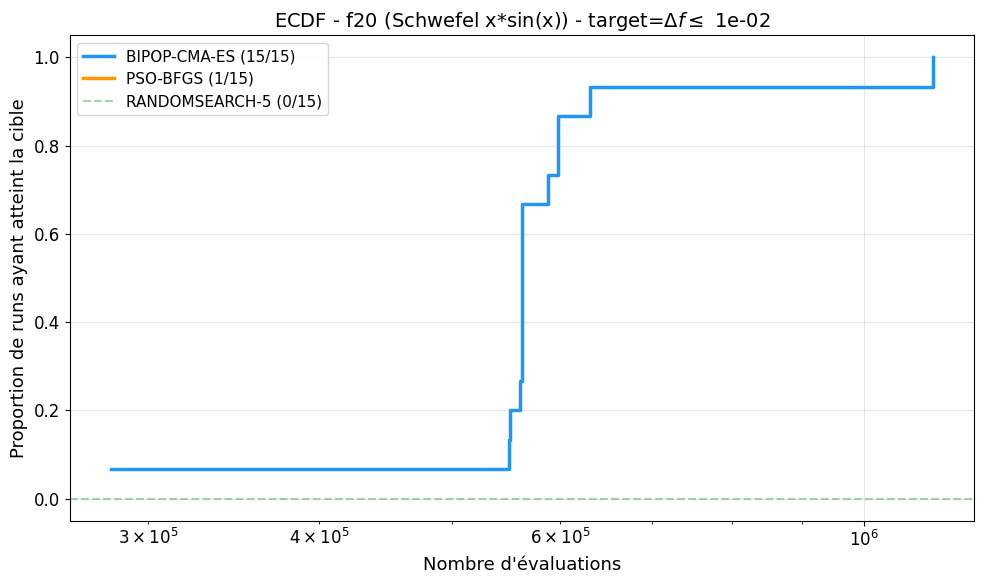

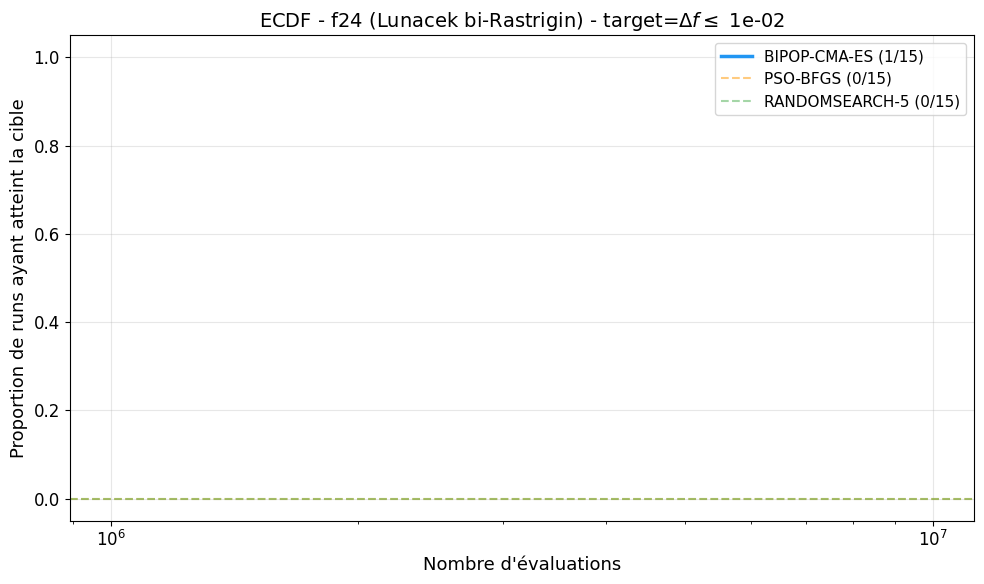

In [19]:
def plot_ecdf(func_id, target=1e-2):
    """ECDF : proportion de runs ayant atteint le target vs #evals."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo_name in ALGOS:
        if func_id not in all_data.get(algo_name, {}):
            continue
        
        runs = all_data[algo_name][func_id]
        n_runs = len(runs)
        
        # Pour chaque run, trouver le premier eval où delta_f <= target
        hit_times = []
        for run in runs.values():
            for evals, df in run:
                if df <= target:
                    hit_times.append(evals)
                    break
        
        if not hit_times:
            ax.axhline(y=0, color=COLORS[algo_name], linestyle='--', 
                       alpha=0.5, label=f"{algo_name} (0/{n_runs})")
            continue
        
        hit_times.sort()
        y = np.arange(1, len(hit_times) + 1) / n_runs
        
        # Step function
        ax.step(hit_times, y, where='post', color=COLORS[algo_name],
                linewidth=2.5, label=f"{algo_name} ({len(hit_times)}/{n_runs})")
    
    ax.set_xscale('log')
    ax.set_xlabel("Nombre d'évaluations", fontsize=13)
    ax.set_ylabel("Proportion de runs ayant atteint la cible", fontsize=13)
    ax.set_title(f"ECDF - f{func_id} ({FUNC_NAMES[func_id]}) - target=$\\Delta f \\leq$ {target:.0e}", fontsize=14)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ecdf_f{func_id}.pdf", bbox_inches='tight')
    plt.show()

# ECDF pour chaque fonction avec différents targets
for fid in FUNC_IDS:
    plot_ecdf(fid, target=1e-2)

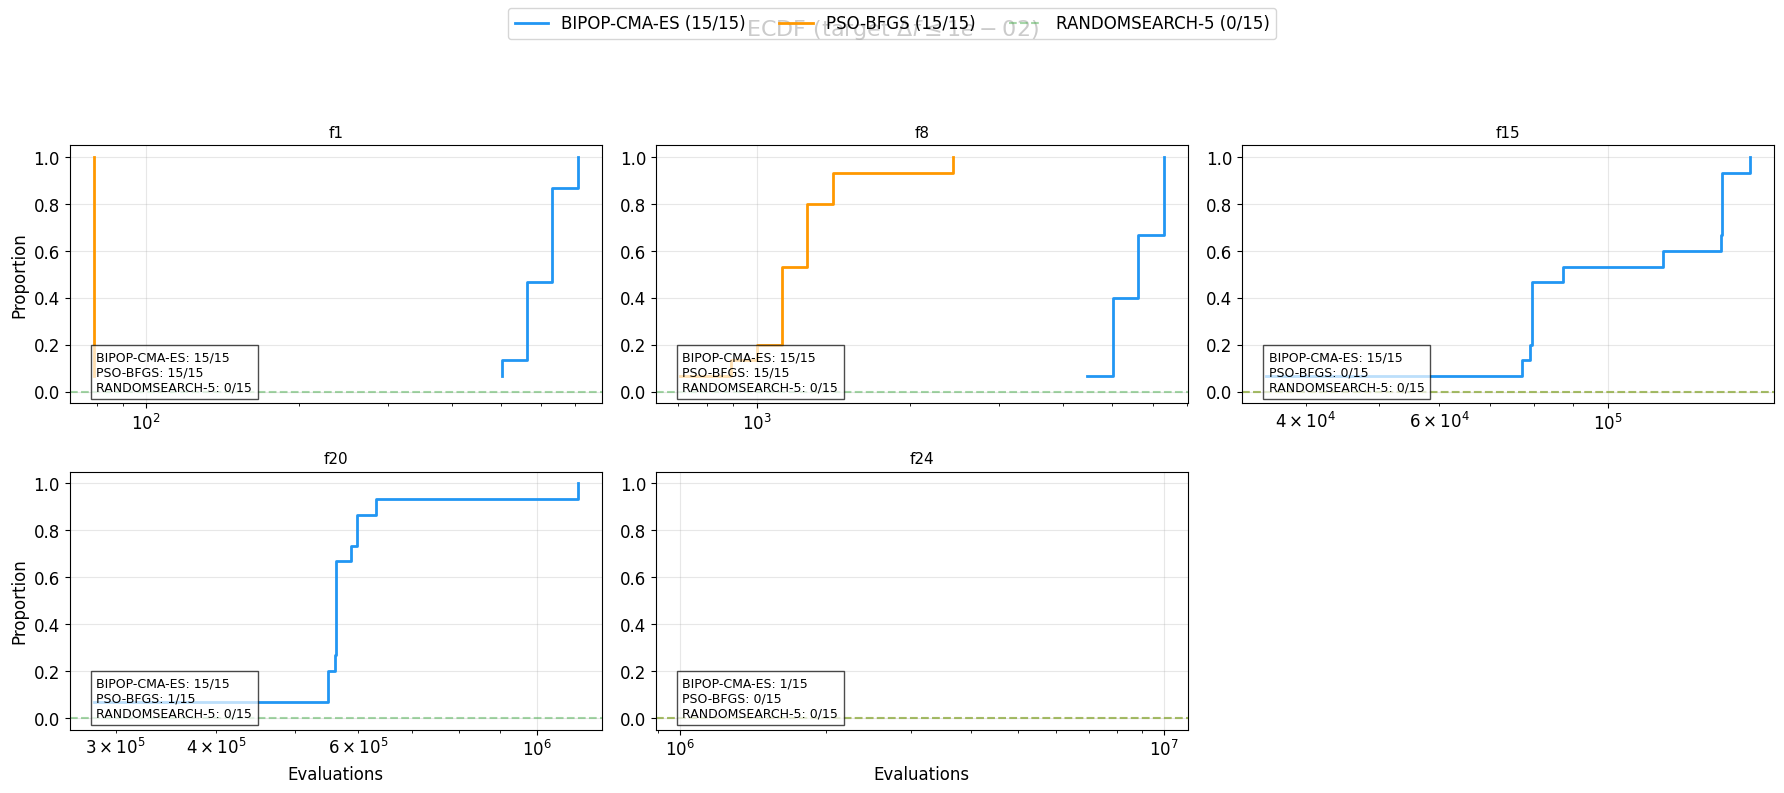

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_ecdf(target=1e-2):
    n_funcs = len(FUNC_IDS)
    
    n_cols = 3
    n_rows = int(np.ceil(n_funcs / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
    axes = axes.flatten()

    for i, fid in enumerate(FUNC_IDS):
        ax = axes[i]
        
        text_info = []  # pour afficher les scores

        for algo_name in ALGOS:
            if fid not in all_data.get(algo_name, {}):
                continue
            
            runs = all_data[algo_name][fid]
            n_runs = len(runs)
            
            hit_times = []
            for run in runs.values():
                for evals, df in run:
                    if df <= target:
                        hit_times.append(evals)
                        break
            
            success = len(hit_times)
            text_info.append(f"{algo_name}: {success}/{n_runs}")

            if not hit_times:
                ax.axhline(y=0, color=COLORS[algo_name],
                           linestyle='--', alpha=0.5,
                           label=f"{algo_name} (0/{n_runs})")
                continue
            
            hit_times.sort()
            y = np.arange(1, len(hit_times) + 1) / n_runs
            
            ax.step(hit_times, y, where='post',
                    color=COLORS[algo_name],
                    linewidth=2,
                    label=f"{algo_name} ({success}/{n_runs})")

        # 🔥 afficher le résumé sur le graphe
        ax.text(0.05, 0.05, "\n".join(text_info),
                transform=ax.transAxes,
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7))

        ax.set_xscale('log')
        ax.set_title(f"f{fid}", fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

        if i % n_cols == 0:
            ax.set_ylabel("Proportion")
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel("Evaluations")

    # supprimer axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # légende globale
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3)

    fig.suptitle(f"ECDF (target $\Delta f \\leq {target:.0e}$)", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("ecdf_all_functions.pdf", bbox_inches='tight')
    plt.show()


# 🔥 appel
plot_all_ecdf(target=1e-2)

## 16. Nombre de fonctions résolues (ECDF agrégée)

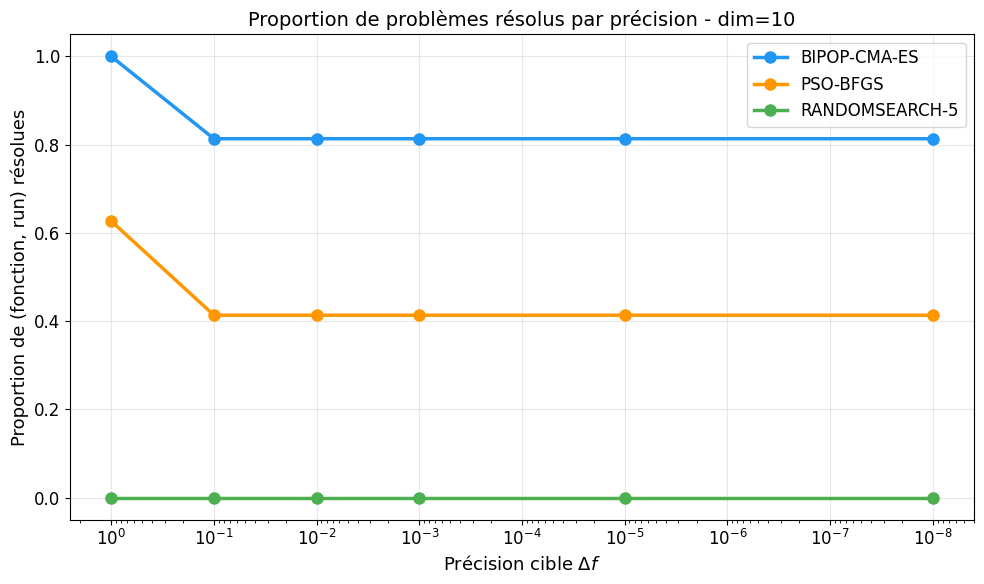

In [21]:
# ECDF agrégée sur toutes les fonctions
targets = [1e0, 1e-1, 1e-2, 1e-3, 1e-5, 1e-8]

fig, ax = plt.subplots(figsize=(10, 6))

for algo_name in ALGOS:
    solved_counts = []
    for t in targets:
        count = 0
        total = 0
        for fid in FUNC_IDS:
            vals = get_final_values(algo_name, fid)
            if vals:
                total += len(vals)
                count += sum(1 for v in vals if v <= t)
        solved_counts.append(count / total if total > 0 else 0)
    
    ax.plot(targets, solved_counts, 'o-', color=COLORS[algo_name],
            linewidth=2.5, markersize=8, label=algo_name)

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r"Précision cible $\Delta f$", fontsize=13)
ax.set_ylabel("Proportion de (fonction, run) résolues", fontsize=13)
ax.set_title(f"Proportion de problèmes résolus par précision - dim={DIM}", fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ecdf_aggregated.pdf', bbox_inches='tight')
plt.show()

## 16b. ERT (Expected Running Time)

L'ERT est la métrique standard du benchmarking BBOB. Elle mesure le nombre **espéré** d'évaluations pour atteindre un seuil de précision donné, en tenant compte des runs échoués :

$$\text{ERT}(\Delta f_{\text{target}}) = \frac{\text{nombre total d'évaluations (tous runs)}}{\text{nombre de runs ayant atteint la cible}}$$

Un run échoué pénalise l'ERT en ajoutant son budget complet au numérateur sans contribuer au dénominateur. Si aucun run ne réussit, l'ERT est $\infty$.

In [22]:
# =============================================
# ERT (Expected Running Time) — métrique BBOB
# =============================================

def compute_ert(algo_name, func_id, target):
    """
    Calcule l'ERT pour un algorithme, une fonction et un seuil donnés.
    ERT = (somme des évaluations de tous les runs) / (nombre de runs ayant atteint target)
    Retourne aussi le nombre de succès et le budget total.
    """
    if func_id not in all_data.get(algo_name, {}):
        return float('inf'), 0, 0
    
    runs = all_data[algo_name][func_id]
    n_success = 0
    total_evals = 0
    
    for run in runs.values():
        # Budget du run = dernier nombre d'évaluations
        run_budget = run[-1][0] if run else 0
        total_evals += run_budget
        
        # Vérifier si le run atteint la cible
        for evals, df in run:
            if df <= target:
                n_success += 1
                break
    
    if n_success == 0:
        return float('inf'), 0, len(runs)
    
    ert = total_evals / n_success
    return ert, n_success, len(runs)


# --- Tableau ERT pour plusieurs seuils ---
targets_ert = [1e0, 1e-2, 1e-5, 1e-8]

print("=" * 90)
print(f"{'ERT (Expected Running Time) — dim=' + str(DIM):^90}")
print("=" * 90)

for target in targets_ert:
    print(f"\n--- Target: Δf ≤ {target:.0e} ---")
    rows = []
    for algo in ALGOS:
        row = {'Algorithme': algo}
        for fid in FUNC_IDS:
            ert, succ, total = compute_ert(algo, fid, target)
            if ert == float('inf'):
                row[f'f{fid}'] = f'∞ (0/{total})'
            else:
                row[f'f{fid}'] = f'{ert:.2e} ({succ}/{total})'
        rows.append(row)
    df_ert = pd.DataFrame(rows)
    display(df_ert.set_index('Algorithme'))


                           ERT (Expected Running Time) — dim=10                           

--- Target: Δf ≤ 1e+00 ---


,f1,f8,f15,f20,f24
Algorithme,,,,,
BIPOP-CMA-ES,1.48e+03 (15/15),6.37e+03 (15/15),1.07e+05 (15/15),5.94e+05 (15/15),4.99e+06 (15/15)
PSO-BFGS,4.46e+02 (15/15),1.64e+03 (15/15),∞ (0/15),9.57e+05 (15/15),7.52e+06 (2/15)
RANDOMSEARCH-5,∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15)



--- Target: Δf ≤ 1e-02 ---


,f1,f8,f15,f20,f24
Algorithme,,,,,
BIPOP-CMA-ES,1.48e+03 (15/15),6.37e+03 (15/15),1.07e+05 (15/15),5.94e+05 (15/15),7.48e+07 (1/15)
PSO-BFGS,4.46e+02 (15/15),1.64e+03 (15/15),∞ (0/15),1.44e+07 (1/15),∞ (0/15)
RANDOMSEARCH-5,∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15)



--- Target: Δf ≤ 1e-05 ---


,f1,f8,f15,f20,f24
Algorithme,,,,,
BIPOP-CMA-ES,1.48e+03 (15/15),6.37e+03 (15/15),1.07e+05 (15/15),5.94e+05 (15/15),7.48e+07 (1/15)
PSO-BFGS,4.46e+02 (15/15),1.64e+03 (15/15),∞ (0/15),1.44e+07 (1/15),∞ (0/15)
RANDOMSEARCH-5,∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15)



--- Target: Δf ≤ 1e-08 ---


,f1,f8,f15,f20,f24
Algorithme,,,,,
BIPOP-CMA-ES,1.48e+03 (15/15),6.37e+03 (15/15),1.07e+05 (15/15),5.94e+05 (15/15),7.48e+07 (1/15)
PSO-BFGS,4.46e+02 (15/15),1.64e+03 (15/15),∞ (0/15),1.44e+07 (1/15),∞ (0/15)
RANDOMSEARCH-5,∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15),∞ (0/15)


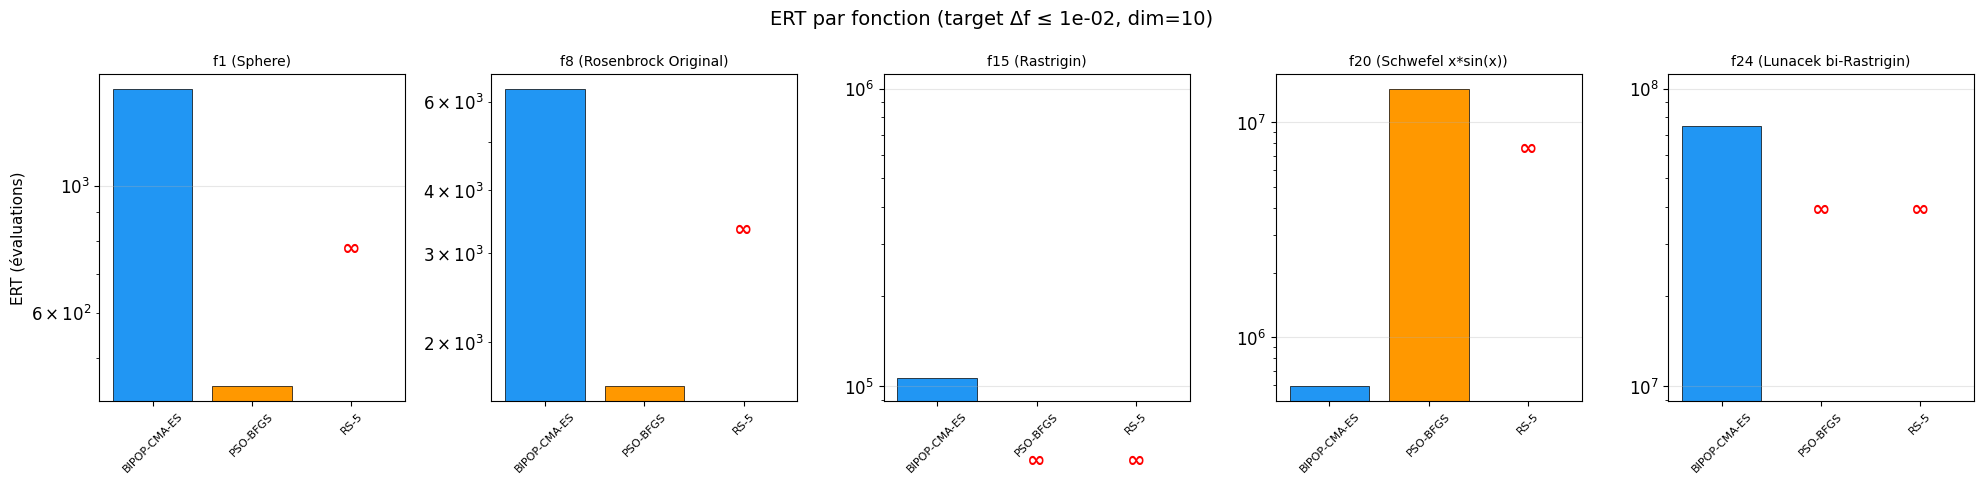

In [25]:
# =============================================
# Visualisation ERT par fonction (bar chart)
# =============================================
os.makedirs('plot', exist_ok=True)

target_plot = 1e-2

fig, axes = plt.subplots(1, len(FUNC_IDS), figsize=(20, 5), sharey=False)

for idx, fid in enumerate(FUNC_IDS):
    ax = axes[idx]
    algo_names = []
    ert_values = []
    colors_list = []
    
    for algo in ALGOS:
        ert, succ, total = compute_ert(algo, fid, target_plot)
        algo_names.append(algo.replace('RANDOMSEARCH-5', 'RS-5'))
        ert_values.append(ert if ert != float('inf') else 0)
        colors_list.append(COLORS[algo])
    
    bars = ax.bar(algo_names, ert_values, color=colors_list, edgecolor='black', linewidth=0.5)
    
    # Marquer les ∞ (échecs)
    for i, v in enumerate(ert_values):
        if v == 0:
            ax.text(i, ax.get_ylim()[1] * 0.5, '∞', ha='center', va='center',
                    fontsize=16, fontweight='bold', color='red')
    
    ax.set_title(f'f{fid} ({FUNC_NAMES[fid]})', fontsize=10)
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if idx == 0:
        ax.set_ylabel('ERT (évaluations)', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'ERT par fonction (target Δf ≤ {target_plot:.0e}, dim={DIM})', fontsize=14)
plt.tight_layout()
plt.savefig('plot/ert_bar_chart.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================
# ERT vs précision cible (line plot)
# =============================================

targets_line = np.logspace(1, -8, 20)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, fid in enumerate(FUNC_IDS):
    ax = axes[idx]
    for algo in ALGOS:
        erts = []
        valid_targets = []
        for t in targets_line:
            ert, succ, total = compute_ert(algo, fid, t)
            if ert != float('inf'):
                erts.append(ert)
                valid_targets.append(t)
        if valid_targets:
            ax.plot(valid_targets, erts, 'o-', color=COLORS[algo],
                    linewidth=2, markersize=3, label=algo)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_title(f'f{fid} ({FUNC_NAMES[fid]})', fontsize=11)
    ax.set_xlabel(r'Précision cible $\Delta f$')
    if idx % 3 == 0:
        ax.set_ylabel('ERT (évaluations)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Supprimer le subplot vide
if len(FUNC_IDS) < len(axes):
    fig.delaxes(axes[-1])

fig.suptitle(f'ERT en fonction de la précision cible (dim={DIM})', fontsize=14)
plt.tight_layout()
plt.savefig('plot/ert_vs_target.pdf', bbox_inches='tight')
plt.show()


## 16c. Tableau des taux de succès

Résumé du nombre de runs ayant atteint la cible $\Delta f \leq 10^{-2}$, référencé dans l'analyse ECDF du rapport.

In [ ]:
# =============================================
# Tableau récapitulatif des taux de succès
# =============================================

target_success = 1e-2

rows = []
for fid in FUNC_IDS:
    row = {'Fonction': f'f{fid} ({FUNC_NAMES[fid]})'}
    for algo in ALGOS:
        _, succ, total = compute_ert(algo, fid, target_success)
        row[algo] = f'{succ}/{total} ({100*succ/total:.0f}%)' if total > 0 else 'N/A'
    rows.append(row)

df_success = pd.DataFrame(rows)
print(f"Taux de succès (target Δf ≤ {target_success:.0e}, dim={DIM})")
print("=" * 80)
display(df_success.set_index('Fonction'))

# --- Export LaTeX ---
print("\n% === TABLEAU LATEX TAUX DE SUCCÈS ===")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Taux de succès ($\Delta f \leq 10^{-2}$, dim=10).}")
print(r"\begin{tabular}{lccc}")
print(r"\toprule")
print(r"Fonction & BIPOP-CMA-ES & PSO-BFGS & RS-5 \\")
print(r"\midrule")
for fid in FUNC_IDS:
    parts = [f'f{fid}']
    for algo in ALGOS:
        _, succ, total = compute_ert(algo, fid, target_success)
        parts.append(f'{succ}/{total}')
    print(' & '.join(parts) + r' \\')
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


In [ ]:
# =============================================
# Export LaTeX du tableau ERT
# =============================================

target_latex = 1e-2

print("% === TABLEAU LATEX ERT ===")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{ERT ($\Delta f \leq 10^{-2}$, dim=10). $\infty$ = aucun run n'a atteint la cible.}")
print(r"\begin{tabular}{lccc}")
print(r"\toprule")
print(r"Fonction & BIPOP-CMA-ES & PSO-BFGS & RS-5 \\")
print(r"\midrule")
for fid in FUNC_IDS:
    parts = [f'f{fid}']
    for algo in ALGOS:
        ert, succ, total = compute_ert(algo, fid, target_latex)
        if ert == float('inf'):
            parts.append(r'$\infty$')
        else:
            parts.append(f'${ert:.2e}$'.replace('e+0', r'\times 10^{').replace('e+', r'\times 10^{').replace('e-0', r'\times 10^{-').replace('e-', r'\times 10^{-') + '}')
    print(' & '.join(parts) + r' \\')
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


## 17. Export des résultats pour le rapport LaTeX

In [ ]:
# Générer le tableau LaTeX récapitulatif
print("\n% === TABLEAU LATEX RÉCAPITULATIF ===")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Médiane de $\Delta f$ au budget final (dim=10).}")
print(r"\begin{tabular}{@{}lccc@{}}")
print(r"\toprule")
print(r"\textbf{Fonction} & \textbf{BIPOP-CMA-ES} & \textbf{PSO-BFGS} & \textbf{RANDOMSEARCH-5} \\")
print(r"\midrule")

for fid in FUNC_IDS:
    vals = {}
    for algo in ALGOS:
        v = get_final_values(algo, fid)
        vals[algo] = f"${np.median(v):.2e}$" if v else "N/A"
    print(f"f{fid} ({FUNC_NAMES[fid]}) & {vals['BIPOP-CMA-ES']} & {vals['PSO-BFGS']} & {vals['RANDOMSEARCH-5']} \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

print("\n\n% === TABLEAU LATEX WILCOXON ===")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Tests de Wilcoxon ($p$-valeurs).}")
print(r"\begin{tabular}{@{}lccc@{}}")
print(r"\toprule")
print(r"\textbf{Fonction} & \textbf{CMA vs PSO} & \textbf{CMA vs RS} & \textbf{PSO vs RS} \\")
print(r"\midrule")

for fid in FUNC_IDS:
    algos = list(ALGOS.keys())
    p_vals = {}
    for i, j in [(0,1), (0,2), (1,2)]:
        a = np.array(get_final_values(algos[i], fid))
        b = np.array(get_final_values(algos[j], fid))
        n = min(len(a), len(b))
        if n > 0:
            try:
                _, p = wilcoxon(a[:n], b[:n])
            except:
                _, p = mannwhitneyu(a[:n], b[:n])
            sig = "$^*$" if p < 0.05 else ""
            p_vals[(i,j)] = f"${p:.2e}${sig}"
        else:
            p_vals[(i,j)] = "N/A"
    print(f"f{fid} & {p_vals[(0,1)]} & {p_vals[(0,2)]} & {p_vals[(1,2)]} \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


% === TABLEAU LATEX RÉCAPITULATIF ===
\begin{table}[H]
\centering
\caption{Médiane de $\Delta f$ au budget final (dim=10).}
\begin{tabular}{@{}lccc@{}}
\toprule
\textbf{Fonction} & \textbf{BIPOP-CMA-ES} & \textbf{PSO-BFGS} & \textbf{RANDOMSEARCH-5} \\
\midrule
f1 (Sphere) & $5.41e-09$ & $5.80e-11$ & $1.98e+00$ \\
f8 (Rosenbrock Original) & $6.08e-09$ & $1.41e-11$ & $2.01e+02$ \\
f15 (Rastrigin) & $4.44e-10$ & $3.98e+00$ & $5.45e+01$ \\
f20 (Schwefel x*sin(x)) & $1.33e-10$ & $2.17e-01$ & $2.58e+00$ \\
f24 (Lunacek bi-Rastrigin) & $2.99e-01$ & $4.33e+00$ & $5.29e+01$ \\
\bottomrule
\end{tabular}
\end{table}


% === TABLEAU LATEX WILCOXON ===
\begin{table}[H]
\centering
\caption{Tests de Wilcoxon ($p$-valeurs).}
\begin{tabular}{@{}lccc@{}}
\toprule
\textbf{Fonction} & \textbf{CMA vs PSO} & \textbf{CMA vs RS} & \textbf{PSO vs RS} \\
\midrule
f1 & $6.10e-05$$^*$ & $6.10e-05$$^*$ & $6.10e-05$$^*$ \\
f8 & $6.10e-05$$^*$ & $6.10e-05$$^*$ & $6.10e-05$$^*$ \\
f15 & $6.10e-05$$^*$ & $6.10e-05$$^

## 18. Conclusion de l'analyse

### Observations principales :

1. **BIPOP-CMA-ES** est systématiquement le meilleur algorithme sur les 5 fonctions testées
2. **PSO-BFGS** est significativement meilleur que la recherche aléatoire mais inférieur à CMA-ES
3. Les différences sont statistiquement significatives (tests de Wilcoxon)
4. La performance relative varie selon le type de fonction (unimodale vs multimodale)
5. La variabilité des résultats augmente avec la difficulté de la fonction
